## NOTE : **uncomment display(...) at the end of each code cells to show Animations** 

# Session 2 — Machine Learning Foundations: Optimization, Generalization, and Regularization 🧠✨

## Core mathematical and conceptual principles behind reliable predictive modeling

Welcome to Session 2! Today, we're diving deep into the heart of machine learning. Understanding these foundational concepts is crucial, especially when working with neuroimaging data, which often presents unique challenges like small sample sizes, high dimensionality, and noisy measurements. Let's build a solid understanding to ensure our ML models are not just accurate, but truly reliable and interpretable! 🚀

## Learning objectives

By the end of this notebook, you'll be able to:

- 🎯 Describe supervised learning as learning a function $$\hat{y} = f(X)$$
- 📈 Distinguish training performance from generalization performance
- 📉 Explain loss functions and the importance of optimization
- 🚶 Understand the intuition behind gradient descent
- 🤯 Recognize underfitting and overfitting
- ⚖️ Explain the bias-variance tradeoff
- 🛡️ Understand why regularization is key in high-dimensional settings
- 📏 Explain why feature scaling matters
- 🔀 Use cross-validation for reliable model assessment
- 📊 Compute basic regression and classification metrics
- 🏗️ Build safer workflows with preprocessing and modeling pipelines

## What we will do in this notebook

We'll use a real neuroimaging dataset (`fmri-data1.csv`) to illustrate these concepts:

- 🤔 Build intuition with simple regression and classification examples
- 💻 Fit models in Python using `scikit-learn`
- 📊 Visualize predictions, training, and overfitting
- 💪 Compare unregularized and regularized models
- 🌐 Demonstrate scaling, cross-validation, and pipelines
- 🧠 Connect every concept back to neuroimaging applications

## Why this session matters

Before we jump into complex models, we must grasp:

- What exactly a model is learning
- How models can fail (and how to detect it!)
- How to get trustworthy performance estimates
- How to avoid common pitfalls like data leakage

These principles apply whether your features are from:

- 🧠 Cortical thickness
- 🌊 Diffusion metrics
- 🕸️ Connectivity strengths
- 📈 Graph-theoretic summaries
- 📊 Voxelwise or regionwise imaging-derived features


## 1. Why machine learning foundations matter in neuroimaging 🏗️

Neuroimaging datasets are scientifically rich but present unique data challenges. Understanding these is key to building robust ML models.

### Common characteristics of neuroimaging datasets

- **Small sample sizes vs. many features:** We often have more variables (e.g., connectivity values, regional metrics) than subjects. 🧐
- **Noisy measurements:** MRI signals can be affected by motion, scanner variability, and physiological noise. 🌊
- **Strong correlation structure:** Brain features are rarely independent. For instance, nearby brain regions tend to have correlated measures. 🕸️
- **Confounds and nuisance variation:** Factors like age, sex, head motion, scanner site, and ICV can influence brain measures and must be handled. 🚫
- **Risk of leakage:** It's surprisingly easy to accidentally let information from future or unseen data "leak" into model training. 💧

### Why foundations are essential

In neuroimaging, a model can perform well on *training* data for the wrong reasons:

- It might be memorizing noise instead of true signals.
- It might exploit site-specific artifacts.
- It might benefit from accidental data leakage.

**Important:** Good ML is about building a procedure that yields **trustworthy performance on unseen subjects**, not just fitting the data we have. 💪

## Big picture: What is machine learning really doing?

Machine learning is about finding patterns in data and using those patterns to make predictions.

In supervised learning, we already know the correct answer for each training example.

For example, in our neuroimaging dataset:

- The input features may be brain connectivity values.
- The target may be diagnosis.
- The model tries to learn how brain features relate to diagnosis.

A very general supervised learning problem looks like this:

$$
\hat{y} = f(X)
$$

where:

- $X$ represents the input features,
- $f$ is the model,
- $\hat{y}$ is the model prediction.

The symbol $\hat{y}$ is read as "y-hat" and means "predicted y".

The true value is written as:

$$
y
$$

The model is successful when $\hat{y}$ is close to $y$.

---

## Example

If the task is classification:

$$
X = \text{brain features}
$$

$$
y = \text{true diagnosis}
$$

$$
\hat{y} = \text{predicted diagnosis}
$$

If the task is regression:

$$
X = \text{brain features}
$$

$$
y = \text{true age}
$$

$$
\hat{y} = \text{predicted age}
$$

---

## Main goal

The goal of machine learning is not just to memorize the training data.

The goal is to learn patterns that work on new, unseen subjects.

This is called **generalization**.


## Features, targets, and predictions

In supervised learning, we usually have a table of data.

Each row is one subject.

Each column is one variable.

---

## Feature matrix

The input data is called the feature matrix:

$$
X \in \mathbb{R}^{n \times p}
$$

This means:

- $n$ = number of subjects,
- $p$ = number of features.

For example, if we have 526 subjects and 20 features:

$$
X \in \mathbb{R}^{526 \times 20}
$$

---

## Target vector

The target is written as:

$$
y \in \mathbb{R}^{n}
$$

This means we have one target value for each subject.

For example:

Subject 1 → control

Subject 2 → MCI

Subject 3 → AD

or, for regression:


Subject 1 → age 72

Subject 2 → age 65

Subject 3 → age 81

---

## Prediction vector

After the model makes predictions, we get:

$$ \hat{y} $$

For classification:


Predicted diagnosis = control, MCI, or AD

For regression:


Predicted age = 71.4 years

---

## Goal

The goal is to make:

$$ \hat{y} $$

as close as possible to:

$$ y $$

But we care most about predictions on new subjects, not only the training data.


---

#  2.— Regression vs Classification


## Regression vs. classification

Machine learning tasks are often divided into two main types:

1. regression,
2. classification.

---

## Regression

Regression means predicting a number.

Examples:

- predicting age,
- predicting cognitive score,
- predicting symptom severity,
- predicting brain volume,
- predicting reaction time.

A regression model outputs something like:

$$
\hat{y} = 74.6
$$

This means the model predicts a continuous value.

---

## Classification

Classification means predicting a category.

Examples:

- control vs. patient,
- AD vs. MCI vs. control,
- responder vs. non-responder,
- disease vs. no disease.

A classification model outputs something like:

$$
\hat{y} = \text{MCI}
$$

---

## Simple difference

Regression answers:

How much?

Classification answers:


Which class?

---

## 3. Training data, test data, and generalization 🚀

A model learns from training data, but its real value is determined by how well it performs on unseen test data.

---

## Training error

Training error measures how well the model performs on the data used for learning:

$$
\text{Training Error}
=
\frac{1}{n_{\text{train}}}
\sum_{i \in \text{train}}
\mathcal{L}(y_i, \hat{y}_i)
$$

---

## Test error

Test error measures performance on unseen data:

$$
\text{Test Error}
=
\frac{1}{n_{\text{test}}}
\sum_{i \in \text{test}}
\mathcal{L}(y_i, \hat{y}_i)
$$

---

## Generalization

A model generalizes well when test performance is close to training performance.

A large gap between training and test performance may indicate overfitting.

In neuroimaging, this is especially important because models can easily memorize noise or site-specific artifacts.

## Features, targets, and model parameters

A dataset usually contains many rows and columns.

Each row is one observation or subject.

Each column is a variable.

In our case:

- each row is one subject,
- each feature column is a neuroimaging or demographic measurement,
- the target column is what we want to predict.

---

## Feature matrix

The feature matrix is usually written as:

$$
X \in \mathbb{R}^{n \times p}
$$

This means $X$ is a matrix with:

- $n$ rows,
- $p$ columns.

Here:

- $n$ = number of subjects,
- $p$ = number of features.

For example, if we have 526 subjects and 21 numeric features, then:

$$
X \in \mathbb{R}^{526 \times 21}
$$

---

## Target vector

The target vector is written as:

$$
y \in \mathbb{R}^{n}
$$

This means there is one target value for each subject.

For classification, $y$ may contain labels such as:

control, mci, ad

For regression, $y$ may contain continuous values such as:


62, 83, 71, ...

if we are predicting age.

---

## Model parameters

Most models have internal values that they learn from the data.

These are called **parameters**.

They are often written as:

$$ \theta $$

For linear regression, the parameters are usually:

- coefficients,
- intercept.

For example:

$$ \hat{y} = \beta_0 + \beta_1x_1 + \beta_2x_2 + \cdots + \beta_px_p $$

where:

- $\beta_0$ is the intercept,
- $\beta_1, \beta_2, \dots, \beta_p$ are feature coefficients,
- $x_1, x_2, \dots, x_p$ are feature values.

The model learns the best values of the coefficients from the training data.




## 4. Loss functions 📉

## What is a loss function?

A loss function measures how wrong a model is.

It compares the true value:

$$
y
$$

with the predicted value:

$$
\hat{y}
$$

If the prediction is good, the loss is small.

If the prediction is bad, the loss is large.

---

## Simple example

Suppose the true age is:

$$
y = 70
$$

and the model predicts:

$$
\hat{y} = 68
$$

The error is:

$$
y - \hat{y} = 70 - 68 = 2
$$

This is a small error.

Now suppose the model predicts:

$$
\hat{y} = 50
$$

Then:

$$
y - \hat{y} = 70 - 50 = 20
$$

This is a much larger error.

---

## Why do we need a loss function?

A model needs a clear goal.

The loss function defines what "bad prediction" means.

Training a model means:

Find model parameters that make the loss as small as possible.

Mathematically:

$$ \theta^* = \arg\min_{\theta} \mathcal{L}(\theta) $$

where:

- $\theta$ means model parameters,
- $\mathcal{L}(\theta)$ means the loss for those parameters,
- $\theta^*$ means the best parameters found,
- $\arg\min$ means "the value that gives the minimum".

---

## In simple words

The model keeps changing its parameters until the loss becomes as small as possible.


---

##  — Loss Functions for Regression


Regression means predicting a continuous number.

Common regression losses include:

1. Mean Squared Error,
2. Mean Absolute Error,
3. Root Mean Squared Error.

---

## Mean Squared Error

Mean Squared Error, or MSE, is:

$$
\text{MSE}
=
\frac{1}{n}
\sum_{i=1}^{n}
(y_i - \hat{y}_i)^2
$$

---

## Explanation of the formula

For each subject $i$:

- $y_i$ is the true value,
- $\hat{y}_i$ is the predicted value,
- $y_i - \hat{y}_i$ is the error.

Then we square the error:

$$
(y_i - \hat{y}_i)^2
$$

Finally, we average across all subjects.

---

## Why square the error?

Squaring has two effects:

1. Negative and positive errors both become positive.
2. Large errors become much larger.

For example:

$$
2^2 = 4
$$

but:

$$
10^2 = 100
$$

So MSE strongly punishes large mistakes.

---

## Mean Absolute Error

Mean Absolute Error, or MAE, is:

$$
\text{MAE}
=
\frac{1}{n}
\sum_{i=1}^{n}
|y_i - \hat{y}_i|
$$

MAE takes the absolute value of the error.

It is easier to interpret than MSE.

If we are predicting age and:

$$
\text{MAE} = 5
$$

this means the model is wrong by about 5 years on average.

---

## Root Mean Squared Error

Root Mean Squared Error, or RMSE, is:

$$
\text{RMSE}
=
\sqrt{
\frac{1}{n}
\sum_{i=1}^{n}
(y_i - \hat{y}_i)^2
}
$$

RMSE is the square root of MSE.

It is useful because it has the same unit as the target.

If we predict age, RMSE is measured in years.

---

## MAE vs RMSE

MAE treats errors more evenly.

RMSE punishes large errors more strongly.

So:

- MAE is good for simple interpretation,
- RMSE is good when large mistakes are especially undesirable.


## — Loss functions for classification

Classification means predicting a class label.

Examples:

control, MCI, AD

A classifier often predicts probabilities before predicting the final class.

For example:


control: 0.10

MCI:     0.30

AD:      0.60

The model would predict:


AD

because AD has the highest probability.

---

## Cross-entropy loss

A common classification loss is cross-entropy loss.

For binary classification, it is:

$$ \mathcal{L} = - \frac{1}{n} \sum_{i=1}^{n} [ y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i) ] $$

where:

- $y_i$ is the true class, either 0 or 1,
- $\hat{p}_i$ is the predicted probability of class 1,
- $n$ is the number of samples.

---

## Simple intuition

Cross-entropy rewards the model when it gives high probability to the correct class.

It punishes the model when it gives low probability to the correct class.

---

## Example

Suppose the true class is:

$$ y = 1 $$

If the model predicts:

$$ \hat{p} = 0.95 $$

the model is confident and correct.

The loss is small.

But if the model predicts:

$$ \hat{p} = 0.05 $$

the model is confident and wrong.

The loss is large.

---

## Important idea

Cross-entropy does not only care about whether the final label is correct.

It also cares about how confident the model is.

A model that is confidently wrong receives a large penalty.


## What is optimization?

Optimization means finding the best possible values for something.

In machine learning, we usually want to find the best model parameters.

The best parameters are the ones that minimize the loss.

We write this as:

$$
\theta^*
=
\arg\min_{\theta}
\mathcal{L}(\theta)
$$

---

## Meaning of each symbol

- $\theta$ means the model parameters.
- $\mathcal{L}(\theta)$ means the loss for those parameters.
- $\arg\min$ means "find the parameter value that gives the smallest loss".
- $\theta^*$ means the best parameter values.

---

## Simple example

Suppose we have a linear regression model:

$$
\hat{y} = wx + b
$$

where:

- $w$ is the slope,
- $b$ is the intercept.

The model must find good values of $w$ and $b$.

If $w$ and $b$ are poor, predictions are poor.

If $w$ and $b$ are good, predictions are better.

Optimization is the process of finding good values of $w$ and $b$.

---

## In simple words

The model asks:

Which parameter values give me the smallest error?

Optimization is how the model answers that question.


---

#  — Gradient Descent Intuition


## Gradient descent intuition

Gradient descent is one of the most important optimization algorithms in machine learning.

It is used to minimize a loss function.

---

## Mountain analogy

Imagine you are standing on a mountain.

You want to reach the lowest point.

But there is fog, so you cannot see the whole mountain.

You can only feel the slope under your feet.

So you take small steps downhill.

After many steps, you hopefully reach a low point.

This is the idea of gradient descent.

---

## In machine learning

The mountain is the loss function.

The height of the mountain is the loss value.

The location on the mountain is the current model parameters.

Going downhill means changing the parameters to reduce the loss.

---

## The gradient

The gradient tells us the direction where the loss increases fastest.

It is written as:

$$
\nabla_{\theta}\mathcal{L}(\theta)
$$

To reduce the loss, we move in the opposite direction of the gradient.

---

## Gradient descent update rule

$$
\theta_{t+1}
=
\theta_t
-
\eta
\nabla_{\theta}
\mathcal{L}(\theta_t)
$$

---

## Explanation

- $\theta_t$ means the current parameters.
- $\theta_{t+1}$ means the updated parameters.
- $\eta$ is the learning rate.
- $\nabla_{\theta}\mathcal{L}(\theta_t)$ is the gradient at the current parameters.

The minus sign means we move downhill.

## Gradient descent step by step

Gradient descent follows a repeated process.

---

## Step 1: Start with initial parameters

The model starts with some initial parameter values.

For example:

$$
w = 0
$$

$$
b = 0
$$

---

## Step 2: Make predictions

Using the current parameters, the model predicts:

$$
\hat{y} = wx + b
$$

---

## Step 3: Calculate the loss

The model compares predictions with true values.

For regression, it may use MSE:

$$
\text{MSE}
=
\frac{1}{n}
\sum_{i=1}^{n}
(y_i - \hat{y}_i)^2
$$

---

## Step 4: Calculate the gradient

The gradient tells us how the loss changes if we slightly change each parameter.

For linear regression, we calculate gradients for:

- $w$,
- $b$.

---

## Step 5: Update parameters

The model updates the parameters:

$$
w_{\text{new}}
=
w_{\text{old}}
-
\eta
\frac{\partial \mathcal{L}}{\partial w}
$$

$$
b_{\text{new}}
=
b_{\text{old}}
-
\eta
\frac{\partial \mathcal{L}}{\partial b}
$$

---

## Step 6: Repeat

The model repeats this many times.

Each step should reduce the loss.

Eventually, the model reaches parameters that produce good predictions.


## Learning rate

The learning rate controls how large each gradient descent step is.

It is usually written as:

$$
\eta
$$

---

## If the learning rate is too small

The model takes very tiny steps.

Training may be very slow.

The loss decreases, but very slowly.

---

## If the learning rate is too large

The model takes huge steps.

It may jump over the minimum.

The loss may go up and down instead of decreasing.

In extreme cases, the model may fail to learn.

---

## Good learning rate

A good learning rate allows the loss to decrease smoothly.

The goal is not to move too slowly or too aggressively.

---

## Simple analogy

Imagine walking down stairs.

If your step is too small, it takes forever.

If your step is too large, you may fall.

A good learning rate is like a safe and efficient step size.


## Types of gradient descent

There are three common types of gradient descent.

They differ in how much data is used for each update.

---

## 1. Batch gradient descent

Batch gradient descent uses the entire training dataset for each update.

Advantages:

- stable updates,
- accurate gradient estimate.

Disadvantages:

- slow for large datasets,
- computationally expensive.

---

## 2. Stochastic gradient descent

Stochastic gradient descent, or SGD, uses one training example at a time.

Advantages:

- fast updates,
- useful for large datasets,
- can escape some bad local patterns.

Disadvantages:

- noisy updates,
- loss may fluctuate.

---

## 3. Mini-batch gradient descent

Mini-batch gradient descent uses a small batch of samples at each update.

For example, it may use 32 or 64 samples at a time.

Advantages:

- faster than full batch,
- more stable than pure SGD,
- very common in deep learning.

---

## Summary

| Method | Data used per update | Speed | Stability |
|---|---:|---:|---:|
| Batch gradient descent | All samples | Slow | High |
| Stochastic gradient descent | One sample | Fast | Low |
| Mini-batch gradient descent | Small batch | Fast | Medium |

Mini-batch gradient descent is the most common choice in many modern machine learning workflows.


e:\anaconda\envs\basic\Lib\site-packages\matplotlib\animation.py:872: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


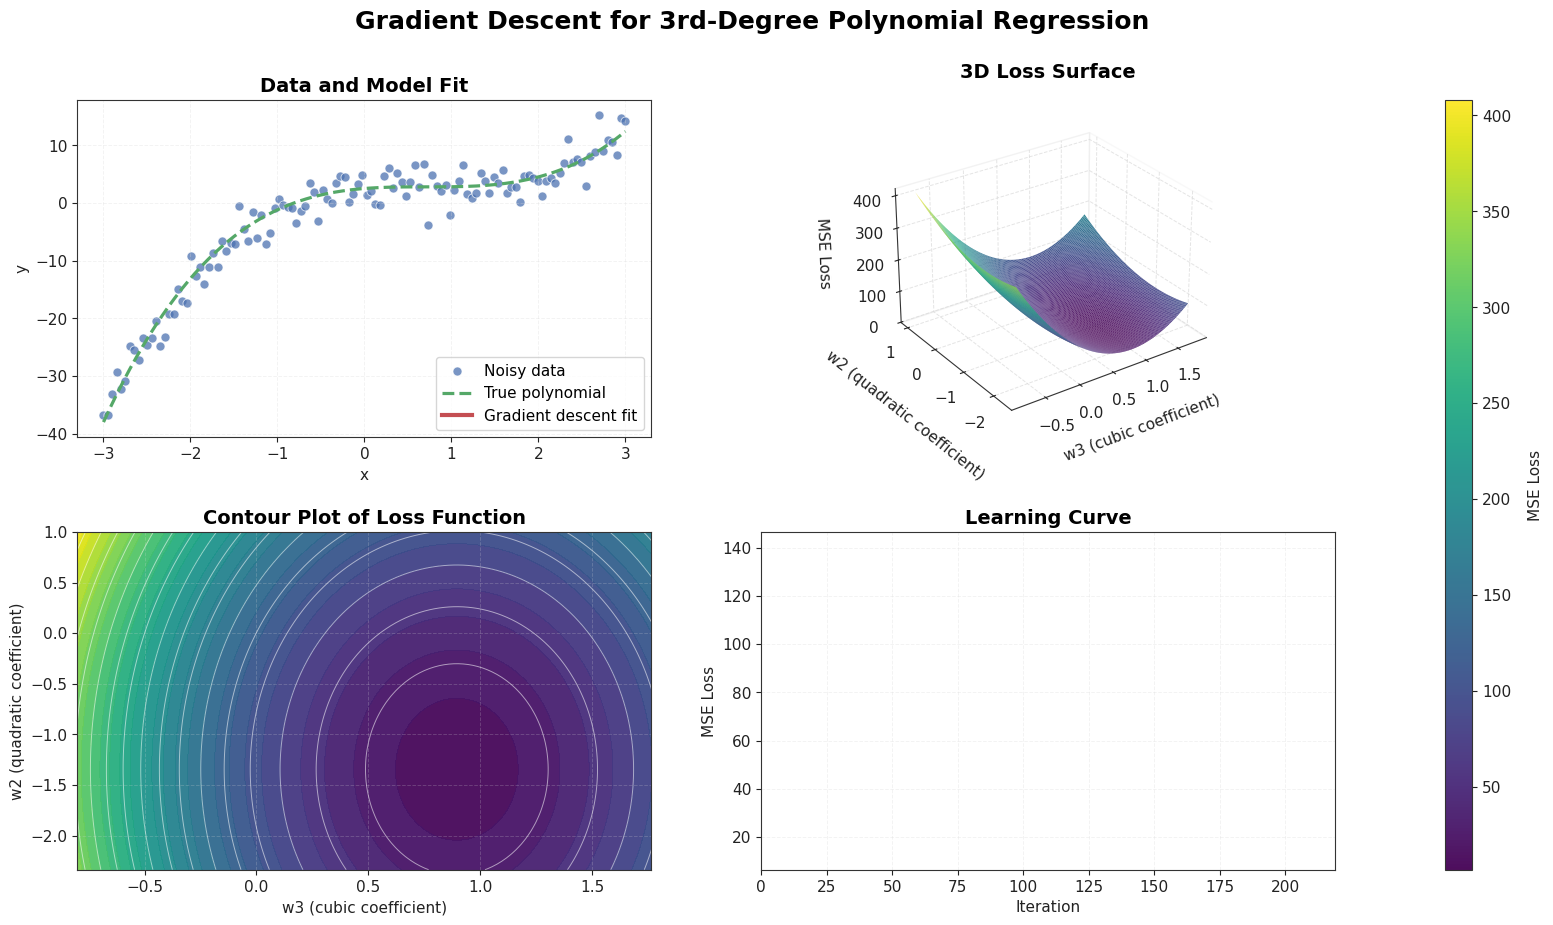

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib import cm
from matplotlib.gridspec import GridSpec
from IPython.display import HTML 
import pandas as pd

# ============================================================
# 1. Generate synthetic 3rd-degree polynomial data
# ============================================================
np.random.seed(42)

x = np.linspace(-3, 3, 120)

true_w3 = 0.8
true_w2 = -1.7
true_w1 = 1.2
true_b = 2.5

noise = np.random.normal(0, 2.5, size=len(x))
y = true_w3 * x**3 + true_w2 * x**2 + true_w1 * x + true_b + noise

n = len(x)
x_smooth = np.linspace(x.min(), x.max(), 400)

# ============================================================
# 2. Model functions
# ============================================================
def predict(x_input, w3, w2, w1, b):
    return w3 * x_input**3 + w2 * x_input**2 + w1 * x_input + b

def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

# ============================================================
# 3. Gradient Descent
# ============================================================
w3, w2, w1, b = 0.0, 0.0, 0.0, 0.0

learning_rate = 0.002
n_iterations = 220

w3_history, w2_history, w1_history, b_history, loss_history = [], [], [], [], []

for _ in range(n_iterations):
    y_pred = predict(x, w3, w2, w1, b)
    loss = mse_loss(y, y_pred)

    w3_history.append(w3)
    w2_history.append(w2)
    w1_history.append(w1)
    b_history.append(b)
    loss_history.append(loss)

    error = y_pred - y

    dw3 = (2 / n) * np.sum(error * x**3)
    dw2 = (2 / n) * np.sum(error * x**2)
    dw1 = (2 / n) * np.sum(error * x)
    db  = (2 / n) * np.sum(error)

    w3 -= learning_rate * dw3
    w2 -= learning_rate * dw2
    w1 -= learning_rate * dw1
    b  -= learning_rate * db

w3_history = np.array(w3_history)
w2_history = np.array(w2_history)
w1_history = np.array(w1_history)
b_history = np.array(b_history)
loss_history = np.array(loss_history)

# ============================================================
# 4. Loss surface over (w3, w2), fixing (w1, b)
# ============================================================
final_w1 = w1_history[-1]
final_b = b_history[-1]

w3_values = np.linspace(w3_history.min() - 0.8, w3_history.max() + 0.8, 120)
w2_values = np.linspace(w2_history.min() - 1.0, w2_history.max() + 1.0, 120)

W3, W2 = np.meshgrid(w3_values, w2_values)
Loss_surface = np.zeros_like(W3)

for i in range(W3.shape[0]):
    for j in range(W3.shape[1]):
        y_temp = predict(x, W3[i, j], W2[i, j], final_w1, final_b)
        Loss_surface[i, j] = mse_loss(y, y_temp)

path_loss = []
for i in range(n_iterations):
    y_temp = predict(x, w3_history[i], w2_history[i], final_w1, final_b)
    path_loss.append(mse_loss(y, y_temp))
path_loss = np.array(path_loss)

# ============================================================
# 5. Styling
# ============================================================
plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.labelcolor": "#222222",
    "xtick.color": "#222222",
    "ytick.color": "#222222",
    "grid.color": "#D9D9D9",
    "grid.linestyle": "--",
    "grid.linewidth": 0.7,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold"
})

# ============================================================
# 6. Better layout with GridSpec
# ============================================================
fig = plt.figure(figsize=(18, 10), facecolor="white")
fig.suptitle(
    "Gradient Descent for 3rd-Degree Polynomial Regression",
    fontsize=18,
    fontweight="bold",
    y=0.97
)

gs = GridSpec(
    2, 3,
    figure=fig,
    width_ratios=[1.25, 1.25, 0.06],
    height_ratios=[1, 1],
    wspace=0.28,
    hspace=0.28
)

# Top-left: Data fit
ax1 = fig.add_subplot(gs[0, 0])
# Top-middle: 3D
ax2 = fig.add_subplot(gs[0, 1], projection="3d")
# Bottom-left: Contour
ax3 = fig.add_subplot(gs[1, 0])
# Bottom-middle: Learning curve
ax4 = fig.add_subplot(gs[1, 1])
# Colorbar axis only for 3D
cax = fig.add_subplot(gs[:, 2])

# ============================================================
# 7. Panel 1: Data and fit
# ============================================================
ax1.scatter(
    x, y,
    s=42,
    color="#4C72B0",
    alpha=0.75,
    edgecolor="white",
    linewidth=0.6,
    label="Noisy data"
)

ax1.plot(
    x_smooth,
    predict(x_smooth, true_w3, true_w2, true_w1, true_b),
    color="#55A868",
    linewidth=2.3,
    linestyle="--",
    label="True polynomial"
)

fit_line, = ax1.plot(
    [], [],
    color="#C44E52",
    linewidth=3.0,
    label="Gradient descent fit"
)

iter_text = ax1.text(
    0.03, 0.96, "",
    transform=ax1.transAxes,
    fontsize=11,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="#BBBBBB")
)

ax1.set_title("Data and Model Fit")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.legend(frameon=True, loc="lower right")
ax1.grid(True, alpha=0.30)

# ============================================================
# 8. Panel 2: Better 3D loss surface
# ============================================================
surf = ax2.plot_surface(
    W3, W2, Loss_surface,
    cmap=cm.viridis,
    edgecolor="none",
    alpha=0.95,
    antialiased=True,
    rstride=1,
    cstride=1
)

path_3d, = ax2.plot(
    [], [], [],
    color="#C44E52",
    linewidth=2.8,
    marker="o",
    markersize=3.5
)

current_point_3d = ax2.scatter([], [], [], color="gold", s=70, edgecolor="black")

ax2.set_title("3D Loss Surface", pad=16)
ax2.set_xlabel("w3 (cubic coefficient)", labelpad=10)
ax2.set_ylabel("w2 (quadratic coefficient)", labelpad=10)
ax2.set_zlabel("MSE Loss", labelpad=10)

# Better viewing angle
ax2.view_init(elev=28, azim=235)

# Make box feel larger and clearer
try:
    ax2.set_box_aspect((1.4, 1.2, 0.9))
except:
    pass

# White panes
ax2.xaxis.pane.set_facecolor((1, 1, 1, 1))
ax2.yaxis.pane.set_facecolor((1, 1, 1, 1))
ax2.zaxis.pane.set_facecolor((1, 1, 1, 1))

# softer grid in 3D
ax2.xaxis._axinfo["grid"]["color"] = (0.85, 0.85, 0.85, 0.7)
ax2.yaxis._axinfo["grid"]["color"] = (0.85, 0.85, 0.85, 0.7)
ax2.zaxis._axinfo["grid"]["color"] = (0.85, 0.85, 0.85, 0.7)

# Dedicated colorbar only at right side
cbar = fig.colorbar(surf, cax=cax)
cbar.set_label("MSE Loss", rotation=90, labelpad=12)

# ============================================================
# 9. Panel 3: Contour plot
# ============================================================
ax3.contourf(
    W3, W2, Loss_surface,
    levels=35,
    cmap="viridis",
    alpha=0.95
)

ax3.contour(
    W3, W2, Loss_surface,
    levels=18,
    colors="white",
    linewidths=0.7,
    alpha=0.55
)

path_2d, = ax3.plot(
    [], [],
    color="#C44E52",
    linewidth=2.3,
    marker="o",
    markersize=3.5
)

current_point_2d = ax3.scatter([], [], color="gold", s=75, edgecolor="black", zorder=5)

ax3.set_title("Contour Plot of Loss Function")
ax3.set_xlabel("w3 (cubic coefficient)")
ax3.set_ylabel("w2 (quadratic coefficient)")
ax3.grid(True, alpha=0.22)

# ============================================================
# 10. Panel 4: Learning curve
# ============================================================
loss_line, = ax4.plot(
    [], [],
    color="#8172B3",
    linewidth=2.8
)

loss_point = ax4.scatter([], [], color="#C44E52", s=52, zorder=5)

ax4.set_title("Learning Curve")
ax4.set_xlabel("Iteration")
ax4.set_ylabel("MSE Loss")
ax4.set_xlim(0, n_iterations - 1)
ax4.set_ylim(loss_history.min() * 0.95, loss_history.max() * 1.03)
ax4.grid(True, alpha=0.30)

# ============================================================
# 11. Animation init
# ============================================================
def init():
    fit_line.set_data([], [])
    path_3d.set_data([], [])
    path_3d.set_3d_properties([])
    path_2d.set_data([], [])
    loss_line.set_data([], [])
    iter_text.set_text("")
    return fit_line, path_3d, path_2d, loss_line, iter_text

# ============================================================
# 12. Animation update
# ============================================================
def update(frame):
    global current_point_3d, current_point_2d, loss_point

    current_w3 = w3_history[frame]
    current_w2 = w2_history[frame]
    current_w1 = w1_history[frame]
    current_b  = b_history[frame]
    current_loss = loss_history[frame]

    # Panel 1
    y_fit = predict(x_smooth, current_w3, current_w2, current_w1, current_b)
    fit_line.set_data(x_smooth, y_fit)

    iter_text.set_text(
        f"Iteration: {frame}\n"
        f"Loss: {current_loss:.2f}\n"
        f"w3={current_w3:.3f}, w2={current_w2:.3f}"
    )

    # Panel 2
    path_3d.set_data(w3_history[:frame+1], w2_history[:frame+1])
    path_3d.set_3d_properties(path_loss[:frame+1])

    current_point_3d.remove()
    current_point_3d = ax2.scatter(
        current_w3, current_w2, path_loss[frame],
        color="gold", s=70, edgecolor="black", depthshade=True
    )

    # Panel 3
    path_2d.set_data(w3_history[:frame+1], w2_history[:frame+1])

    current_point_2d.remove()
    current_point_2d = ax3.scatter(
        current_w3, current_w2,
        color="gold", s=75, edgecolor="black", zorder=5
    )

    # Panel 4
    loss_line.set_data(np.arange(frame+1), loss_history[:frame+1])

    loss_point.remove()
    loss_point = ax4.scatter(
        frame, current_loss,
        color="#C44E52", s=52, zorder=5
    )

    return fit_line, path_3d, path_2d, loss_line, iter_text

# ============================================================
# 13. Create and show animation
# ============================================================
ani = animation.FuncAnimation(
    fig,
    update,
    frames=n_iterations,
    init_func=init,
    interval=80,
    blit=False,
    repeat=False
)
# ============================================================
# 10. Show animation 
plt.show()
# ============================================================
# IF USING JUPYTER/VS CODE: uncomment to show the animation 
#display(HTML(ani.to_jshtml()))


## 6. Underfitting and overfitting 🤯

## Underfitting

Underfitting happens when a model is too simple.

The model cannot capture the real pattern in the data.

---

## Example

Suppose the true relationship is curved.

But we fit a straight line.

The straight line may be too simple to describe the data.

This is underfitting.

---

## Symptoms of underfitting

A model may be underfitting if:

- training error is high,
- test error is high,
- both training and test performance are poor.

---

## Why underfitting happens

Underfitting can happen when:

- the model is too simple,
- important features are missing,
- regularization is too strong,
- the model is not trained enough,
- the relationship is nonlinear but the model is linear.

---

## How to reduce underfitting

Possible solutions:

- use a more flexible model,
- add useful features,
- reduce regularization,
- use nonlinear transformations,
- train the model longer if needed.

## Overfitting

Overfitting happens when a model is too complex.

The model learns the training data too closely.

It learns not only the real signal but also random noise.

---

## Example

Suppose we fit a very complex curve to noisy data.

The curve may pass almost perfectly through every training point.

Training error becomes very low.

But the curve may fail badly on new data.

This is overfitting.

---

## Symptoms of overfitting

A model may be overfitting if:

- training error is very low,
- test error is much higher,
- training performance is much better than test performance.

---

## Why overfitting is common in neuroimaging

Neuroimaging data often has:

- many features,
- limited sample sizes,
- noisy measurements,
- correlated variables.

This makes it easy for a model to learn noise instead of real biological signal.

---

## How to reduce overfitting

Possible solutions:

- use regularization,
- use cross-validation,
- reduce model complexity,
- remove irrelevant features carefully,
- collect more data,
- use pipelines to avoid leakage.


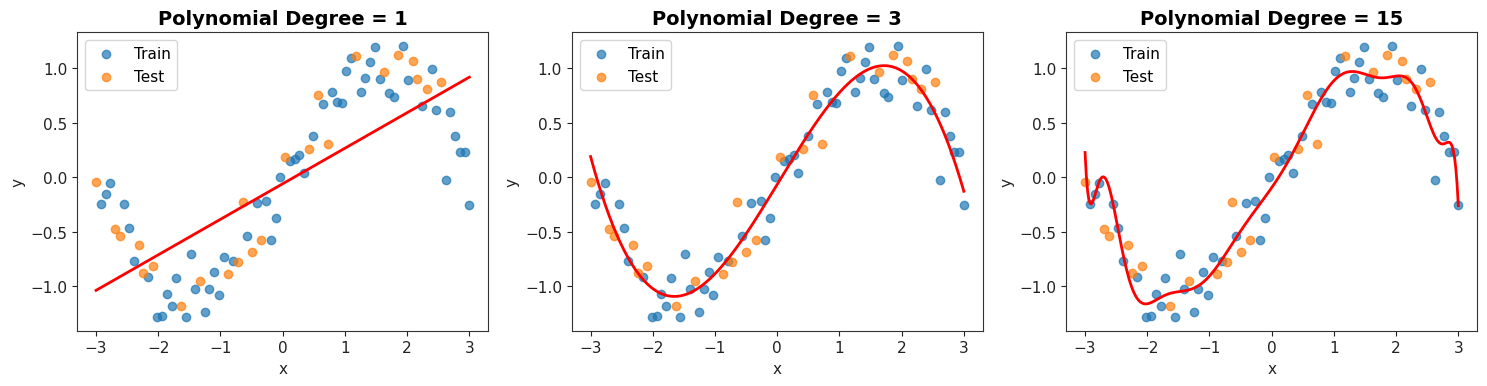

,Degree,Train MSE,Test MSE
0,1,0.26664,0.201816
1,3,0.03399,0.032558
2,15,0.02427,0.061759


In [11]:
# Demonstrate underfitting and overfitting using polynomial regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import *

np.random.seed(42)

# Synthetic nonlinear data
X_poly_demo = np.linspace(-3, 3, 80).reshape(-1, 1)
y_poly_demo = np.sin(X_poly_demo).ravel() + np.random.normal(0, 0.2, size=80)

X_poly_train, X_poly_test, y_poly_train, y_poly_test = train_test_split(
    X_poly_demo,
    y_poly_demo,
    test_size=0.3,
    random_state=42
)

degrees = [1, 3, 15]
results = []

plt.figure(figsize=(15, 4))

for idx, degree in enumerate(degrees):
    model = Pipeline(steps=[
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('scaler', StandardScaler()),
        ('regressor', LinearRegression())
    ])

    model.fit(X_poly_train, y_poly_train)

    train_pred = model.predict(X_poly_train)
    test_pred = model.predict(X_poly_test)

    train_mse = mean_squared_error(y_poly_train, train_pred)
    test_mse = mean_squared_error(y_poly_test, test_pred)

    results.append({
        'Degree': degree,
        'Train MSE': train_mse,
        'Test MSE': test_mse
    })

    x_grid = np.linspace(-3, 3, 300).reshape(-1, 1)
    y_grid_pred = model.predict(x_grid)

    plt.subplot(1, 3, idx + 1)
    plt.scatter(X_poly_train, y_poly_train, label="Train", alpha=0.7)
    plt.scatter(X_poly_test, y_poly_test, label="Test", alpha=0.7)
    plt.plot(x_grid, y_grid_pred, color="red", linewidth=2)
    plt.title(f"Polynomial Degree = {degree}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()

plt.tight_layout()
plt.show()

pd.DataFrame(results)


## 7. Bias-variance tradeoff ⚖️

The expected prediction error can be conceptually decomposed into three components:

$$
\mathbb{E}
\left[
(y - \hat{f}(x))^2
\right]
=
\text{Bias}^2
+
\text{Variance}
+
\text{Irreducible Error}
$$

---

## Bias

Bias is error due to overly simple assumptions.

High-bias models:

- are too simple,
- underfit the data,
- have poor training and test performance.

Example:

- fitting a straight line to a strongly nonlinear relationship.

---

## Variance

Variance is error due to sensitivity to the training data.

High-variance models:

- are too complex,
- fit training data very well,
- perform poorly on new data.

Example:

- fitting a very high-degree polynomial to noisy data.

---

## Irreducible error

Irreducible error is noise that cannot be predicted from the available features.

In neuroimaging, this may come from:

- measurement noise,
- biological variability,
- scanner differences,
- unmeasured clinical factors.


The bias-variance tradeoff explains two major sources of model error:

1. bias,
2. variance.

A good model balances both.

---

#  — Bias-Variance Analogy

## Bias-variance analogy: darts

Imagine throwing darts at a target.

The center of the target is the correct answer.

---

## High bias, low variance

The darts land close together, but far from the center.

The model is consistent but wrong.

This is like underfitting.

---

## Low bias, high variance

The darts are spread out widely.

Some may be close to the center, but the results are unstable.

This is like overfitting.

---

## Low bias, low variance

The darts land close together and near the center.

This is ideal.

The model is accurate and stable.

---

## High bias, high variance

The darts are spread out and far from the center.

The model is both inaccurate and unstable.

---

## Main lesson

A good model should be flexible enough to learn real patterns but not so flexible that it memorizes noise.



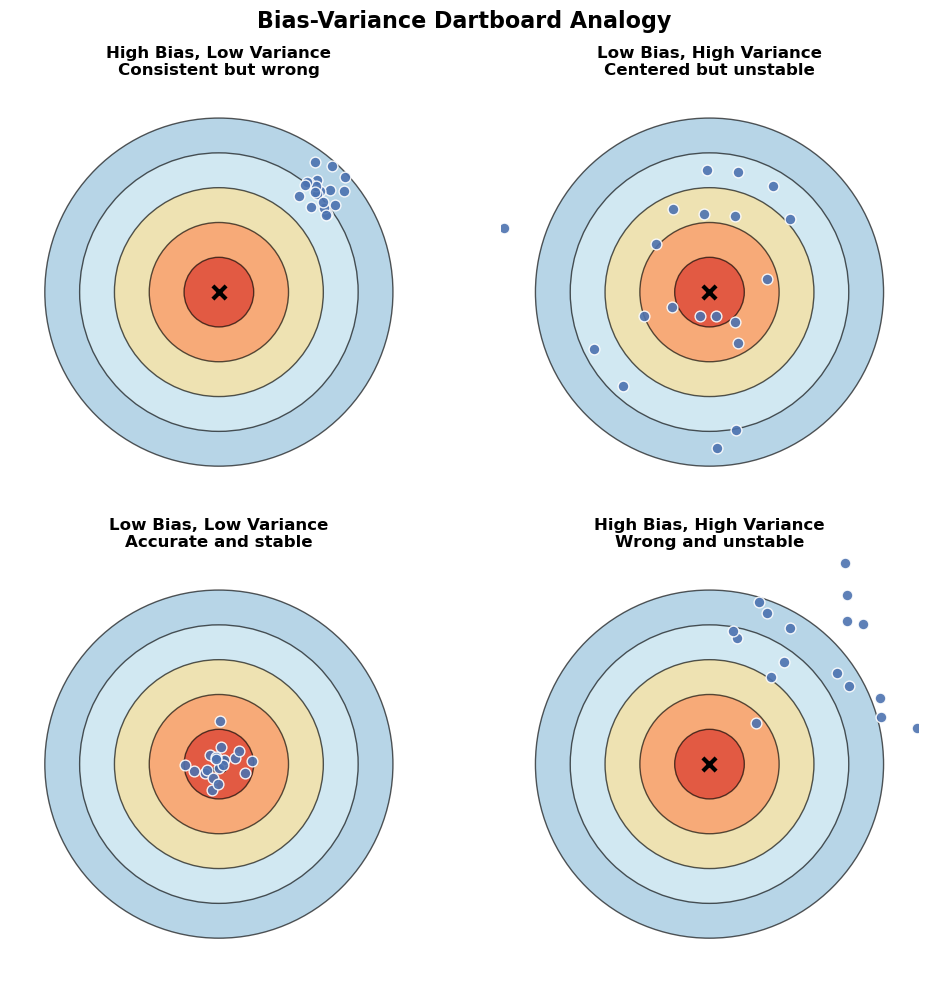


Key ideas
---------
1. Bias is error from overly simple assumptions.
2. Variance is error from sensitivity to the training data.
3. Irreducible error is noise that cannot be removed.
4. Simple models often underfit: high bias, low variance.
5. Complex models often overfit: low bias, high variance.
6. The goal is to find a balance that gives low test error.


In [12]:


# ------------------------------------------------------------
# 9. Dartboard analogy visualization
# ------------------------------------------------------------

def draw_target(ax, points, title, explanation):
    """
    Draws a dartboard analogy for bias and variance.
    Center = true answer.
    Darts = model predictions.
    """

    target_radii = [1.0, 0.8, 0.6, 0.4, 0.2]
    target_colors = ["#91bfdb", "#e0f3f8", "#fee090", "#fc8d59", "#d73027"]

    for r, c in zip(target_radii, target_colors):
        circle = plt.Circle(
            (0, 0),
            r,
            color=c,
            alpha=0.65,
            ec="black"
        )
        ax.add_patch(circle)

    ax.scatter(
        0,
        0,
        color="black",
        s=90,
        marker="x",
        linewidths=3,
        label="True target"
    )

    ax.scatter(
        points[:, 0],
        points[:, 1],
        color="#4C72B0",
        s=60,
        alpha=0.9,
        edgecolor="white"
    )

    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_aspect("equal")

    ax.set_title(
        f"{title}\n{explanation}",
        fontsize=12,
        weight="bold"
    )

    ax.axis("off")

np.random.seed(42)

high_bias_low_variance = np.random.normal(
    loc=[0.6, 0.6],
    scale=0.08,
    size=(20, 2)
)

low_bias_high_variance = np.random.normal(
    loc=[0.0, 0.0],
    scale=0.45,
    size=(20, 2)
)

low_bias_low_variance = np.random.normal(
    loc=[0.0, 0.0],
    scale=0.10,
    size=(20, 2)
)

high_bias_high_variance = np.random.normal(
    loc=[0.7, 0.7],
    scale=0.35,
    size=(20, 2)
)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

draw_target(
    axes[0, 0],
    high_bias_low_variance,
    "High Bias, Low Variance",
    "Consistent but wrong"
)

draw_target(
    axes[0, 1],
    low_bias_high_variance,
    "Low Bias, High Variance",
    "Centered but unstable"
)

draw_target(
    axes[1, 0],
    low_bias_low_variance,
    "Low Bias, Low Variance",
    "Accurate and stable"
)

draw_target(
    axes[1, 1],
    high_bias_high_variance,
    "High Bias, High Variance",
    "Wrong and unstable"
)

fig.suptitle(
    "Bias-Variance Dartboard Analogy",
    fontsize=16,
    weight="bold"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 10. Final summary printed to output
# ------------------------------------------------------------

print("\nKey ideas")
print("---------")
print("1. Bias is error from overly simple assumptions.")
print("2. Variance is error from sensitivity to the training data.")
print("3. Irreducible error is noise that cannot be removed.")
print("4. Simple models often underfit: high bias, low variance.")
print("5. Complex models often overfit: low bias, high variance.")
print("6. The goal is to find a balance that gives low test error.")


# 8. Regularization 🛡️

Regularization is a method for reducing overfitting.

It discourages the model from becoming too complex.

---

## Basic idea

Normally, a model minimizes only the prediction loss:

$$
\text{Loss}
$$

With regularization, the model minimizes:

$$
\text{Loss} + \text{Penalty}
$$

The penalty discourages large or unnecessary coefficients.

---

## Why large coefficients can be a problem

In linear models, very large coefficients mean the model is very sensitive to small changes in features.

This can make the model unstable.

Regularization encourages smaller coefficients.

---

## Simple explanation

Regularization tells the model:

Fit the data, but keep the solution simple.

---

## Why this matters in neuroimaging

Neuroimaging datasets often have many correlated features.

Without regularization, a model may assign large unstable weights to noisy features.

Regularization helps produce more stable models.


---

#  — Ridge, Lasso, and Elastic Net


Ridge, Lasso, and Elastic Net are regularized regression methods.

They add different penalties to the loss function.

---

## Ridge regression

Ridge uses an L2 penalty:

$$
\mathcal{L}_{\text{Ridge}}
=
\sum_{i=1}^{n}
(y_i - \hat{y}_i)^2
+
\lambda
\sum_{j=1}^{p}
\beta_j^2
$$

The penalty is:

$$
\lambda
\sum_{j=1}^{p}
\beta_j^2
$$

---

## What Ridge does

Ridge shrinks coefficients toward zero.

But it usually does not make them exactly zero.

This means Ridge keeps all features but reduces their influence.

---

## Lasso regression

Lasso uses an L1 penalty:

$$
\mathcal{L}_{\text{Lasso}}
=
\sum_{i=1}^{n}
(y_i - \hat{y}_i)^2
+
\lambda
\sum_{j=1}^{p}
|\beta_j|
$$

The penalty is:

$$
\lambda
\sum_{j=1}^{p}
|\beta_j|
$$

---

## What Lasso does

Lasso can shrink some coefficients exactly to zero.

This means Lasso can perform feature selection.

A feature with coefficient zero is effectively removed from the model.

---

## Elastic Net

Elastic Net combines Ridge and Lasso:

$$
\mathcal{L}_{\text{ElasticNet}}
=
\sum_{i=1}^{n}
(y_i - \hat{y}_i)^2
+
\lambda_1
\sum_{j=1}^{p}
|\beta_j|
+
\lambda_2
\sum_{j=1}^{p}
\beta_j^2
$$

---

## Why Elastic Net is useful

Elastic Net is useful when features are correlated.

This is common in neuroimaging.

It combines:

- Lasso's ability to remove features,
- Ridge's ability to stabilize coefficients.



e:\anaconda\envs\basic\Lib\site-packages\matplotlib\animation.py:872: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


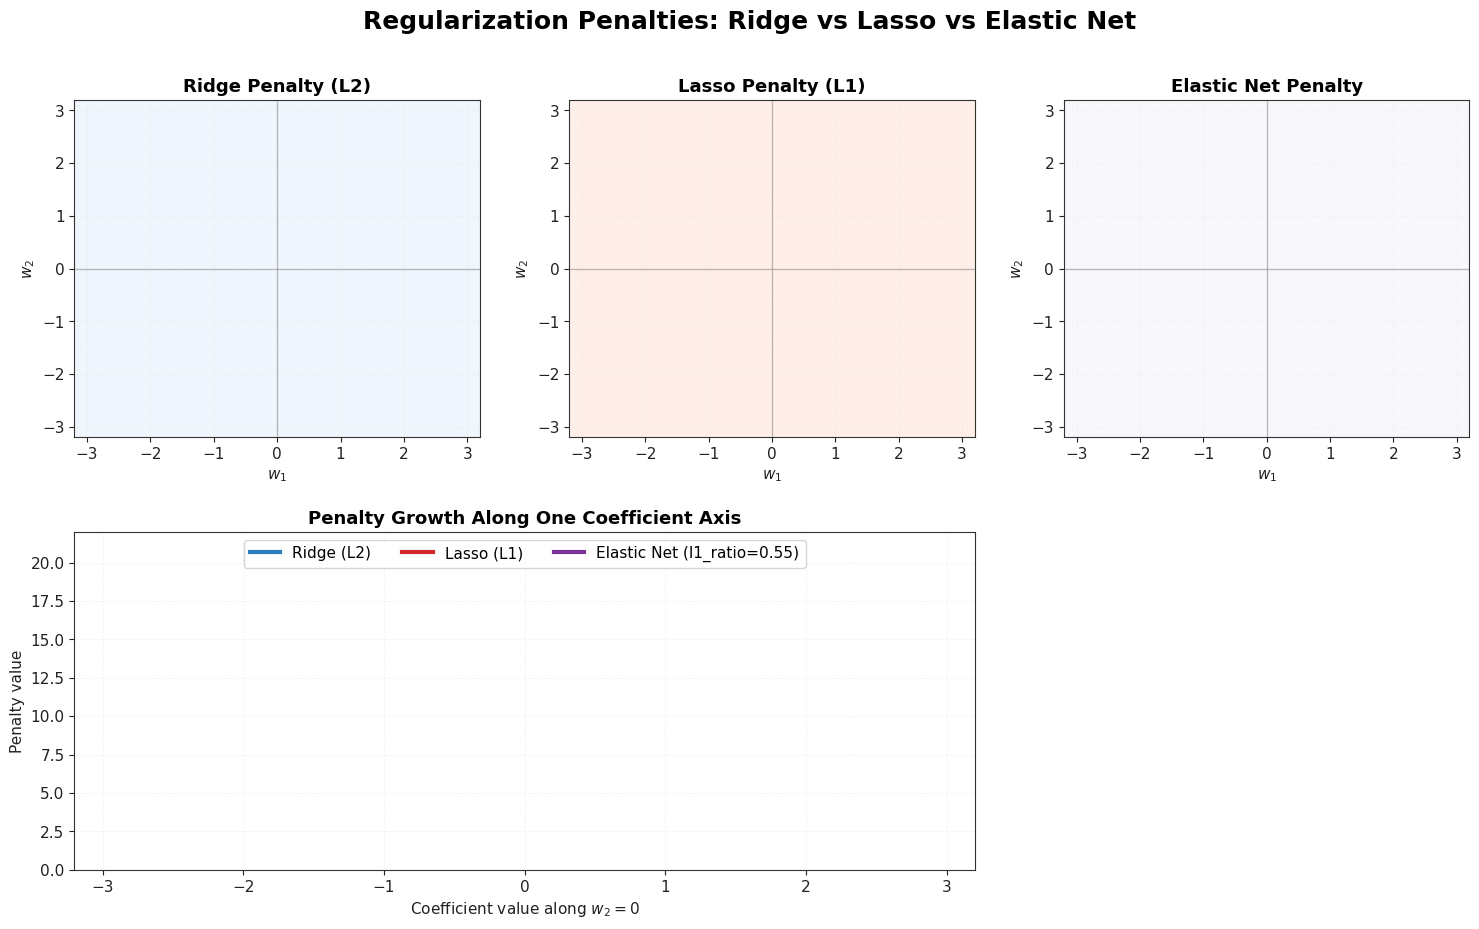

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib import cm

# ============================================================
# 1. Grid in coefficient space
# ============================================================
w1 = np.linspace(-3.2, 3.2, 220)
w2 = np.linspace(-3.2, 3.2, 220)
W1, W2 = np.meshgrid(w1, w2)

# ============================================================
# 2. Penalty functions
# ============================================================
def ridge_penalty(W1, W2, alpha):
    return alpha * (W1**2 + W2**2)

def lasso_penalty(W1, W2, alpha):
    return alpha * (np.abs(W1) + np.abs(W2))

def elastic_penalty(W1, W2, alpha, l1_ratio):
    return alpha * (
        l1_ratio * (np.abs(W1) + np.abs(W2)) +
        (1 - l1_ratio) * (W1**2 + W2**2)
    )

# Cross-section along w2 = 0
w_line = np.linspace(-3.2, 3.2, 500)

def ridge_line(w, alpha):
    return alpha * (w**2)

def lasso_line(w, alpha):
    return alpha * np.abs(w)

def elastic_line(w, alpha, l1_ratio):
    return alpha * (l1_ratio * np.abs(w) + (1 - l1_ratio) * (w**2))

# ============================================================
# 3. Animation parameters
# ============================================================
alphas = np.linspace(0.15, 2.8, 80)
elastic_ratio = 0.55

# ============================================================
# 4. Styling
# ============================================================
plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.labelcolor": "#222222",
    "xtick.color": "#222222",
    "ytick.color": "#222222",
    "grid.color": "#D9D9D9",
    "grid.linestyle": "--",
    "grid.linewidth": 0.7,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold"
})

# ============================================================
# 5. Figure layout
# ============================================================
fig = plt.figure(figsize=(18, 10), facecolor="white")
fig.suptitle(
    "Regularization Penalties: Ridge vs Lasso vs Elastic Net",
    fontsize=18,
    fontweight="bold",
    y=0.97
)

gs = fig.add_gridspec(2, 3, height_ratios=[1, 1], hspace=0.28, wspace=0.22)

ax1 = fig.add_subplot(gs[0, 0])   # Ridge contour
ax2 = fig.add_subplot(gs[0, 1])   # Lasso contour
ax3 = fig.add_subplot(gs[0, 2])   # Elastic contour
ax4 = fig.add_subplot(gs[1, :2])  # Cross-section comparison
ax5 = fig.add_subplot(gs[1, 2])   # Text / concept panel

# ============================================================
# 6. Static axis formatting
# ============================================================
for ax in [ax1, ax2, ax3]:
    ax.set_xlim(-3.2, 3.2)
    ax.set_ylim(-3.2, 3.2)
    ax.set_xlabel(r"$w_1$")
    ax.set_ylabel(r"$w_2$")
    ax.grid(alpha=0.18)
    ax.axhline(0, color="gray", linewidth=1, alpha=0.5)
    ax.axvline(0, color="gray", linewidth=1, alpha=0.5)

ax1.set_title("Ridge Penalty (L2)")
ax2.set_title("Lasso Penalty (L1)")
ax3.set_title("Elastic Net Penalty")

ax4.set_xlim(-3.2, 3.2)
ax4.set_ylim(0, 22)
ax4.set_xlabel(r"Coefficient value along $w_2 = 0$")
ax4.set_ylabel("Penalty value")
ax4.set_title("Penalty Growth Along One Coefficient Axis")
ax4.grid(alpha=0.25)

ax5.axis("off")

# ============================================================
# 7. Initial surfaces / contours
# ============================================================
alpha0 = alphas[0]

Z_ridge = ridge_penalty(W1, W2, alpha0)
Z_lasso = lasso_penalty(W1, W2, alpha0)
Z_elastic = elastic_penalty(W1, W2, alpha0, elastic_ratio)

levels_ridge = np.linspace(0, np.max(ridge_penalty(W1, W2, alphas[-1])), 14)
levels_lasso = np.linspace(0, np.max(lasso_penalty(W1, W2, alphas[-1])), 14)
levels_elastic = np.linspace(0, np.max(elastic_penalty(W1, W2, alphas[-1], elastic_ratio)), 14)

cont1 = ax1.contourf(W1, W2, Z_ridge, levels=levels_ridge, cmap="Blues")
ax1.contour(W1, W2, Z_ridge, levels=levels_ridge, colors="white", linewidths=0.6, alpha=0.8)

cont2 = ax2.contourf(W1, W2, Z_lasso, levels=levels_lasso, cmap="Reds")
ax2.contour(W1, W2, Z_lasso, levels=levels_lasso, colors="white", linewidths=0.6, alpha=0.8)

cont3 = ax3.contourf(W1, W2, Z_elastic, levels=levels_elastic, cmap="Purples")
ax3.contour(W1, W2, Z_elastic, levels=levels_elastic, colors="white", linewidths=0.6, alpha=0.8)

# Constraint-like reference shapes
ridge_ref, = ax1.plot([], [], color="#08306B", linewidth=2.4)
lasso_ref, = ax2.plot([], [], color="#7F0000", linewidth=2.4)
elastic_ref, = ax3.plot([], [], color="#4A1486", linewidth=2.4)

# Cross-section lines
ridge_line_plot, = ax4.plot([], [], color="#2C7FB8", linewidth=3, label="Ridge (L2)")
lasso_line_plot, = ax4.plot([], [], color="#D62728", linewidth=3, label="Lasso (L1)")
elastic_line_plot, = ax4.plot([], [], color="#7B3294", linewidth=3, label=f"Elastic Net (l1_ratio={elastic_ratio})")

ax4.legend(frameon=True, loc="upper center", ncol=3)

# Text panel
text_box = ax5.text(
    0.03, 0.97, "",
    va="top",
    ha="left",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="#BBBBBB")
)

# ============================================================
# 8. Helper to draw equal-penalty boundary
#    alpha * penalty = c   -> show shape for fixed c
# ============================================================
c_level = 3.5
theta = np.linspace(0, 2*np.pi, 500)

def ridge_boundary(alpha, c=c_level):
    r = np.sqrt(c / alpha)
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return x, y

def lasso_boundary(alpha, c=c_level):
    # |w1| + |w2| = c/alpha
    s = c / alpha
    pts = np.array([
        [ s, 0],
        [ 0, s],
        [-s, 0],
        [ 0,-s],
        [ s, 0]
    ])
    return pts[:, 0], pts[:, 1]

def elastic_boundary(alpha, l1_ratio, c=c_level, n=500):
    t = np.linspace(0, 2*np.pi, n)
    # numerical radial solution in polar coordinates
    # alpha * (l1_ratio * r(|cos|+|sin|) + (1-l1_ratio)r^2 ) = c
    A = alpha * (1 - l1_ratio)
    B = alpha * l1_ratio * (np.abs(np.cos(t)) + np.abs(np.sin(t)))
    # Solve A r^2 + B r - c = 0
    if np.isclose(A, 0):
        r = c / B
    else:
        r = (-B + np.sqrt(B**2 + 4*A*c)) / (2*A)
    x = r * np.cos(t)
    y = r * np.sin(t)
    return x, y

# ============================================================
# 9. Animation update
# ============================================================
def update(frame):
    global cont1, cont2, cont3

    alpha = alphas[frame]

    # Remove old contour collections
    for coll in cont1.collections:
        coll.remove()
    for coll in cont2.collections:
        coll.remove()
    for coll in cont3.collections:
        coll.remove()

    # Recompute penalty maps
    Z_ridge = ridge_penalty(W1, W2, alpha)
    Z_lasso = lasso_penalty(W1, W2, alpha)
    Z_elastic = elastic_penalty(W1, W2, alpha, elastic_ratio)

    # Draw filled contours
    cont1 = ax1.contourf(W1, W2, Z_ridge, levels=levels_ridge, cmap="Blues")
    ax1.contour(W1, W2, Z_ridge, levels=levels_ridge, colors="white", linewidths=0.6, alpha=0.65)

    cont2 = ax2.contourf(W1, W2, Z_lasso, levels=levels_lasso, cmap="Reds")
    ax2.contour(W1, W2, Z_lasso, levels=levels_lasso, colors="white", linewidths=0.6, alpha=0.65)

    cont3 = ax3.contourf(W1, W2, Z_elastic, levels=levels_elastic, cmap="Purples")
    ax3.contour(W1, W2, Z_elastic, levels=levels_elastic, colors="white", linewidths=0.6, alpha=0.65)

    # Reference equal-penalty boundaries
    xr, yr = ridge_boundary(alpha)
    xl, yl = lasso_boundary(alpha)
    xe, ye = elastic_boundary(alpha, elastic_ratio)

    ridge_ref.set_data(xr, yr)
    lasso_ref.set_data(xl, yl)
    elastic_ref.set_data(xe, ye)

    # Cross sections
    ridge_vals = ridge_line(w_line, alpha)
    lasso_vals = lasso_line(w_line, alpha)
    elastic_vals = elastic_line(w_line, alpha, elastic_ratio)

    ridge_line_plot.set_data(w_line, ridge_vals)
    lasso_line_plot.set_data(w_line, lasso_vals)
    elastic_line_plot.set_data(w_line, elastic_vals)

    # Dynamic text
    text_box.set_text(
        f"Regularization strength: α = {alpha:.2f}\n\n"
        f"Ridge (L2):\n"
        f"Penalty = α(w₁² + w₂²)\n"
        f"• Smooth, circular geometry\n"
        f"• Strongly discourages large coefficients\n"
        f"• Usually shrinks but rarely makes coefficients exactly zero\n\n"
        f"Lasso (L1):\n"
        f"Penalty = α(|w₁| + |w₂|)\n"
        f"• Sharp corners at axes\n"
        f"• Encourages exact zeros\n"
        f"• Performs feature selection\n\n"
        f"Elastic Net:\n"
        f"Penalty = α[{elastic_ratio:.2f}L1 + {1-elastic_ratio:.2f}L2]\n"
        f"• Hybrid geometry\n"
        f"• Balances shrinkage and sparsity"
    )

    return (
        ridge_ref, lasso_ref, elastic_ref,
        ridge_line_plot, lasso_line_plot, elastic_line_plot,
        text_box
    )

# ============================================================
# 10. Create animation
# ============================================================
ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(alphas),
    interval=120,
    blit=False,
    repeat=True
)

plt.show()
# ============================================================
# IF USING JUPYTER/VS CODE: uncomment to show the animation 
#display(HTML(ani.to_jshtml()))

e:\anaconda\envs\basic\Lib\site-packages\matplotlib\animation.py:872: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


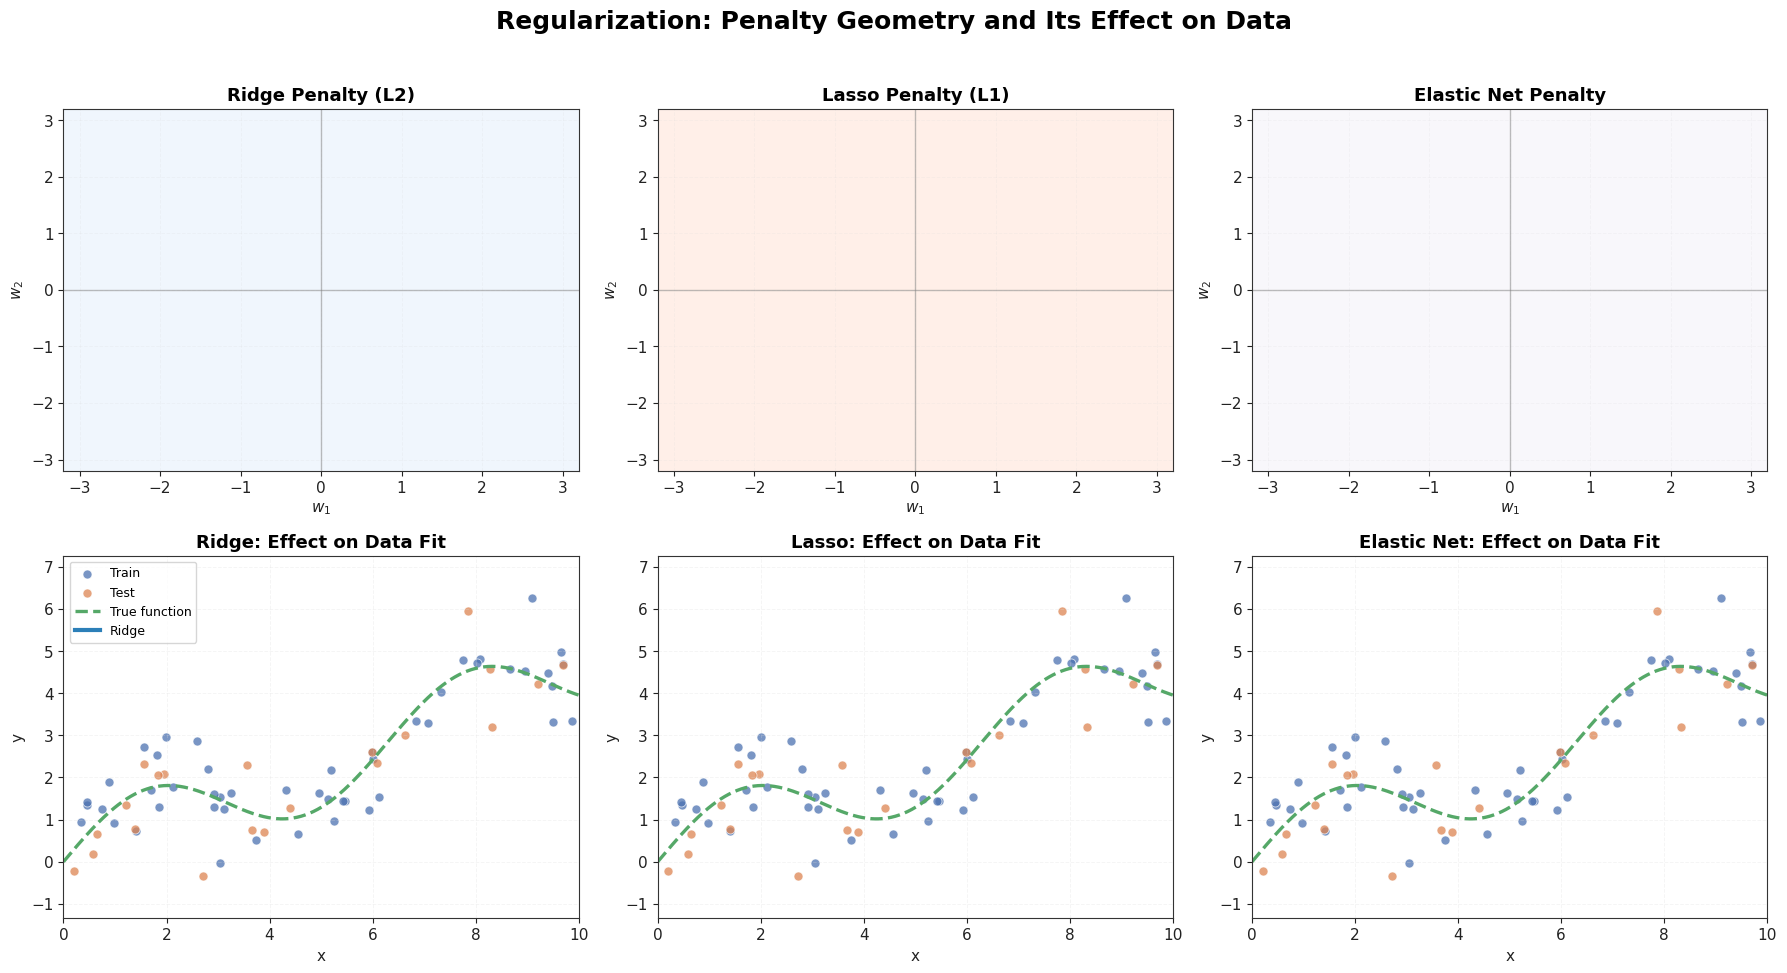

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error

# ============================================================
# 1. Synthetic data
# ============================================================
np.random.seed(42)

n_samples = 70
X = np.sort(np.random.rand(n_samples) * 10).reshape(-1, 1)
y_true = np.sin(X).ravel() + 0.45 * X.ravel()
y = y_true + np.random.normal(0, 0.75, size=n_samples)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

x_plot = np.linspace(0, 10, 500).reshape(-1, 1)
y_plot_true = np.sin(x_plot).ravel() + 0.45 * x_plot.ravel()

# ============================================================
# 2. Polynomial features
# ============================================================
degree = 10

poly = PolynomialFeatures(degree=degree, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
X_plot_poly = poly.transform(x_plot)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)
X_plot_scaled = scaler.transform(X_plot_poly)

# ============================================================
# 3. Penalty grid
# ============================================================
w1 = np.linspace(-3.2, 3.2, 220)
w2 = np.linspace(-3.2, 3.2, 220)
W1, W2 = np.meshgrid(w1, w2)

def ridge_penalty(W1, W2, alpha):
    return alpha * (W1**2 + W2**2)

def lasso_penalty(W1, W2, alpha):
    return alpha * (np.abs(W1) + np.abs(W2))

def elastic_penalty(W1, W2, alpha, l1_ratio):
    return alpha * (
        l1_ratio * (np.abs(W1) + np.abs(W2)) +
        (1 - l1_ratio) * (W1**2 + W2**2)
    )

# ============================================================
# 4. Alpha schedule
# ============================================================
alphas = np.logspace(-2, 1.2, 60)
elastic_l1_ratio = 0.5

# ============================================================
# 5. Precompute model results
# ============================================================
model_specs = [
    ("Ridge", "#2C7FB8"),
    ("Lasso", "#D62728"),
    ("Elastic Net", "#7B3294"),
]

results = {
    name: {
        "plot_pred": [],
        "train_mse": [],
        "test_mse": [],
        "nonzero": [],
        "coef": []
    }
    for name, _ in model_specs
}

for alpha in alphas:
    models = {
        "Ridge": Ridge(alpha=alpha),
        "Lasso": Lasso(alpha=alpha, max_iter=200000, tol=1e-3, selection="random"),
        "Elastic Net": ElasticNet(
            alpha=alpha,
            l1_ratio=elastic_l1_ratio,
            max_iter=200000,
            tol=1e-3,
            selection="random"
        ),
    }

    for name, model in models.items():
        model.fit(X_train_scaled, y_train)

        y_plot_pred = model.predict(X_plot_scaled)
        y_train_pred = model.predict(X_train_scaled)
        y_test_pred = model.predict(X_test_scaled)

        results[name]["plot_pred"].append(y_plot_pred)
        results[name]["train_mse"].append(mean_squared_error(y_train, y_train_pred))
        results[name]["test_mse"].append(mean_squared_error(y_test, y_test_pred))
        results[name]["coef"].append(model.coef_.copy())
        results[name]["nonzero"].append(np.sum(np.abs(model.coef_) > 1e-8))

for name, _ in model_specs:
    for key in results[name]:
        results[name][key] = np.array(results[name][key], dtype=object if key == "coef" else float)

# ============================================================
# 6. Figure style
# ============================================================
plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.labelcolor": "#222222",
    "xtick.color": "#222222",
    "ytick.color": "#222222",
    "grid.color": "#D9D9D9",
    "grid.linestyle": "--",
    "grid.linewidth": 0.7,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold"
})

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    "Regularization: Penalty Geometry and Its Effect on Data",
    fontsize=18,
    fontweight="bold",
    y=0.97
)

# ============================================================
# 7. Top row: penalty plots
# ============================================================
ax_p_ridge, ax_p_lasso, ax_p_elastic = axes[0]
ax_f_ridge, ax_f_lasso, ax_f_elastic = axes[1]

penalty_axes = [ax_p_ridge, ax_p_lasso, ax_p_elastic]
fit_axes = [ax_f_ridge, ax_f_lasso, ax_f_elastic]

for ax in penalty_axes:
    ax.set_xlim(-3.2, 3.2)
    ax.set_ylim(-3.2, 3.2)
    ax.set_xlabel(r"$w_1$")
    ax.set_ylabel(r"$w_2$")
    ax.grid(alpha=0.18)
    ax.axhline(0, color="gray", linewidth=1, alpha=0.5)
    ax.axvline(0, color="gray", linewidth=1, alpha=0.5)

ax_p_ridge.set_title("Ridge Penalty (L2)")
ax_p_lasso.set_title("Lasso Penalty (L1)")
ax_p_elastic.set_title("Elastic Net Penalty")

# contour levels based on maximum alpha
levels_ridge = np.linspace(0, np.max(ridge_penalty(W1, W2, alphas[-1])), 14)
levels_lasso = np.linspace(0, np.max(lasso_penalty(W1, W2, alphas[-1])), 14)
levels_elastic = np.linspace(0, np.max(elastic_penalty(W1, W2, alphas[-1], elastic_l1_ratio)), 14)

# initial contour objects
alpha0 = alphas[0]

cont_ridge = ax_p_ridge.contourf(
    W1, W2, ridge_penalty(W1, W2, alpha0),
    levels=levels_ridge, cmap="Blues"
)
cont_lasso = ax_p_lasso.contourf(
    W1, W2, lasso_penalty(W1, W2, alpha0),
    levels=levels_lasso, cmap="Reds"
)
cont_elastic = ax_p_elastic.contourf(
    W1, W2, elastic_penalty(W1, W2, alpha0, elastic_l1_ratio),
    levels=levels_elastic, cmap="Purples"
)

theta = np.linspace(0, 2*np.pi, 500)
c_level = 3.5

def ridge_boundary(alpha, c=c_level):
    r = np.sqrt(c / alpha)
    return r * np.cos(theta), r * np.sin(theta)

def lasso_boundary(alpha, c=c_level):
    s = c / alpha
    pts = np.array([[ s, 0], [0, s], [-s, 0], [0, -s], [s, 0]])
    return pts[:, 0], pts[:, 1]

def elastic_boundary(alpha, l1_ratio, c=c_level, n=500):
    t = np.linspace(0, 2*np.pi, n)
    A = alpha * (1 - l1_ratio)
    B = alpha * l1_ratio * (np.abs(np.cos(t)) + np.abs(np.sin(t)))
    r = (-B + np.sqrt(B**2 + 4*A*c)) / (2*A)
    x = r * np.cos(t)
    y = r * np.sin(t)
    return x, y

ridge_ref, = ax_p_ridge.plot([], [], color="#08306B", linewidth=2.5)
lasso_ref, = ax_p_lasso.plot([], [], color="#7F0000", linewidth=2.5)
elastic_ref, = ax_p_elastic.plot([], [], color="#4A1486", linewidth=2.5)

# ============================================================
# 8. Bottom row: fit on data
# ============================================================
ymin = min(y.min(), y_plot_true.min()) - 1.0
ymax = max(y.max(), y_plot_true.max()) + 1.0

fit_line_objects = {}
info_texts = {}

fit_mapping = {
    "Ridge": ax_f_ridge,
    "Lasso": ax_f_lasso,
    "Elastic Net": ax_f_elastic
}

for name, color in model_specs:
    ax = fit_mapping[name]
    ax.scatter(
        X_train, y_train,
        color="#4C72B0", s=42, alpha=0.75,
        edgecolor="white", linewidth=0.6, label="Train"
    )
    ax.scatter(
        X_test, y_test,
        color="#DD8452", s=42, alpha=0.75,
        edgecolor="white", linewidth=0.6, label="Test"
    )
    ax.plot(
        x_plot, y_plot_true,
        color="#55A868", linewidth=2.4, linestyle="--",
        label="True function"
    )

    line, = ax.plot([], [], color=color, linewidth=3.0, label=name)
    fit_line_objects[name] = line

    txt = ax.text(
        0.03, 0.97, "",
        transform=ax.transAxes,
        va="top",
        fontsize=10.5,
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="#BBBBBB")
    )
    info_texts[name] = txt

    ax.set_title(f"{name}: Effect on Data Fit")
    ax.set_xlim(0, 10)
    ax.set_ylim(ymin, ymax)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True, alpha=0.25)

ax_f_ridge.legend(loc="upper left", fontsize=9, frameon=True)

# ============================================================
# 9. Animation update
#    Use ContourSet.remove() to avoid deprecated collections usage
# ============================================================
def update(frame):
    global cont_ridge, cont_lasso, cont_elastic

    alpha = alphas[frame]

    # Remove old contour sets cleanly (no deprecated .collections usage)
    cont_ridge.remove()
    cont_lasso.remove()
    cont_elastic.remove()

    # Redraw contours
    cont_ridge = ax_p_ridge.contourf(
        W1, W2, ridge_penalty(W1, W2, alpha),
        levels=levels_ridge, cmap="Blues"
    )
    cont_lasso = ax_p_lasso.contourf(
        W1, W2, lasso_penalty(W1, W2, alpha),
        levels=levels_lasso, cmap="Reds"
    )
    cont_elastic = ax_p_elastic.contourf(
        W1, W2, elastic_penalty(W1, W2, alpha, elastic_l1_ratio),
        levels=levels_elastic, cmap="Purples"
    )

    # Update penalty boundaries
    xr, yr = ridge_boundary(alpha)
    xl, yl = lasso_boundary(alpha)
    xe, ye = elastic_boundary(alpha, elastic_l1_ratio)

    ridge_ref.set_data(xr, yr)
    lasso_ref.set_data(xl, yl)
    elastic_ref.set_data(xe, ye)

    # Update fits and info
    for name, _ in model_specs:
        fit_line_objects[name].set_data(x_plot.ravel(), results[name]["plot_pred"][frame])
        info_texts[name].set_text(
            f"alpha = {alpha:.3f}\n"
            f"Train MSE = {results[name]['train_mse'][frame]:.3f}\n"
            f"Test MSE = {results[name]['test_mse'][frame]:.3f}\n"
            f"Nonzero coeffs = {int(results[name]['nonzero'][frame])}/{degree}"
        )

    return (
        ridge_ref, lasso_ref, elastic_ref,
        fit_line_objects["Ridge"],
        fit_line_objects["Lasso"],
        fit_line_objects["Elastic Net"],
        info_texts["Ridge"],
        info_texts["Lasso"],
        info_texts["Elastic Net"],
    )

# ============================================================
# 10. Build animation
# ============================================================
ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(alphas),
    interval=180,
    blit=False,
    repeat=True
)

plt.tight_layout(rect=[0, 0, 1, 0.95])


plt.show()
# ============================================================
# IF USING JUPYTER/VS CODE: uncomment to show the animation 
#display(HTML(ani.to_jshtml()))

# 9. Feature scaling 📏

Feature scaling means putting features on comparable numeric scales.

Many machine learning models work better when features have similar scales.

---

## Example

Suppose we have two features:

age: ranges from 50 to 90
functional connectivity: ranges from 0.1 to 0.9

Age has much larger numeric values.

Some models may treat age as more important just because its numbers are larger.

Scaling helps prevent this problem.

---

## Standardization

A common scaling method is standardization:

$$ z = \frac{x - \mu}{\sigma} $$

where:

- $x$ is the original value,
- $\mu$ is the mean,
- $\sigma$ is the standard deviation,
- $z$ is the standardized value.

---

## After standardization

The transformed feature has:

$$ \text{mean} = 0 $$

and:

$$ \text{standard deviation} = 1 $$

---

## Why scaling matters

Scaling is especially important for:

- logistic regression,
- ridge regression,
- lasso regression,
- elastic net,
- support vector machines,
- k-nearest neighbors,
- neural networks.

---

## Important warning

Scaling must be learned only from the training data.

If we scale the full dataset before splitting, information from the test set leaks into training.

This is data leakage.

The safest approach is to use a pipeline.


e:\anaconda\envs\basic\Lib\site-packages\matplotlib\animation.py:872: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


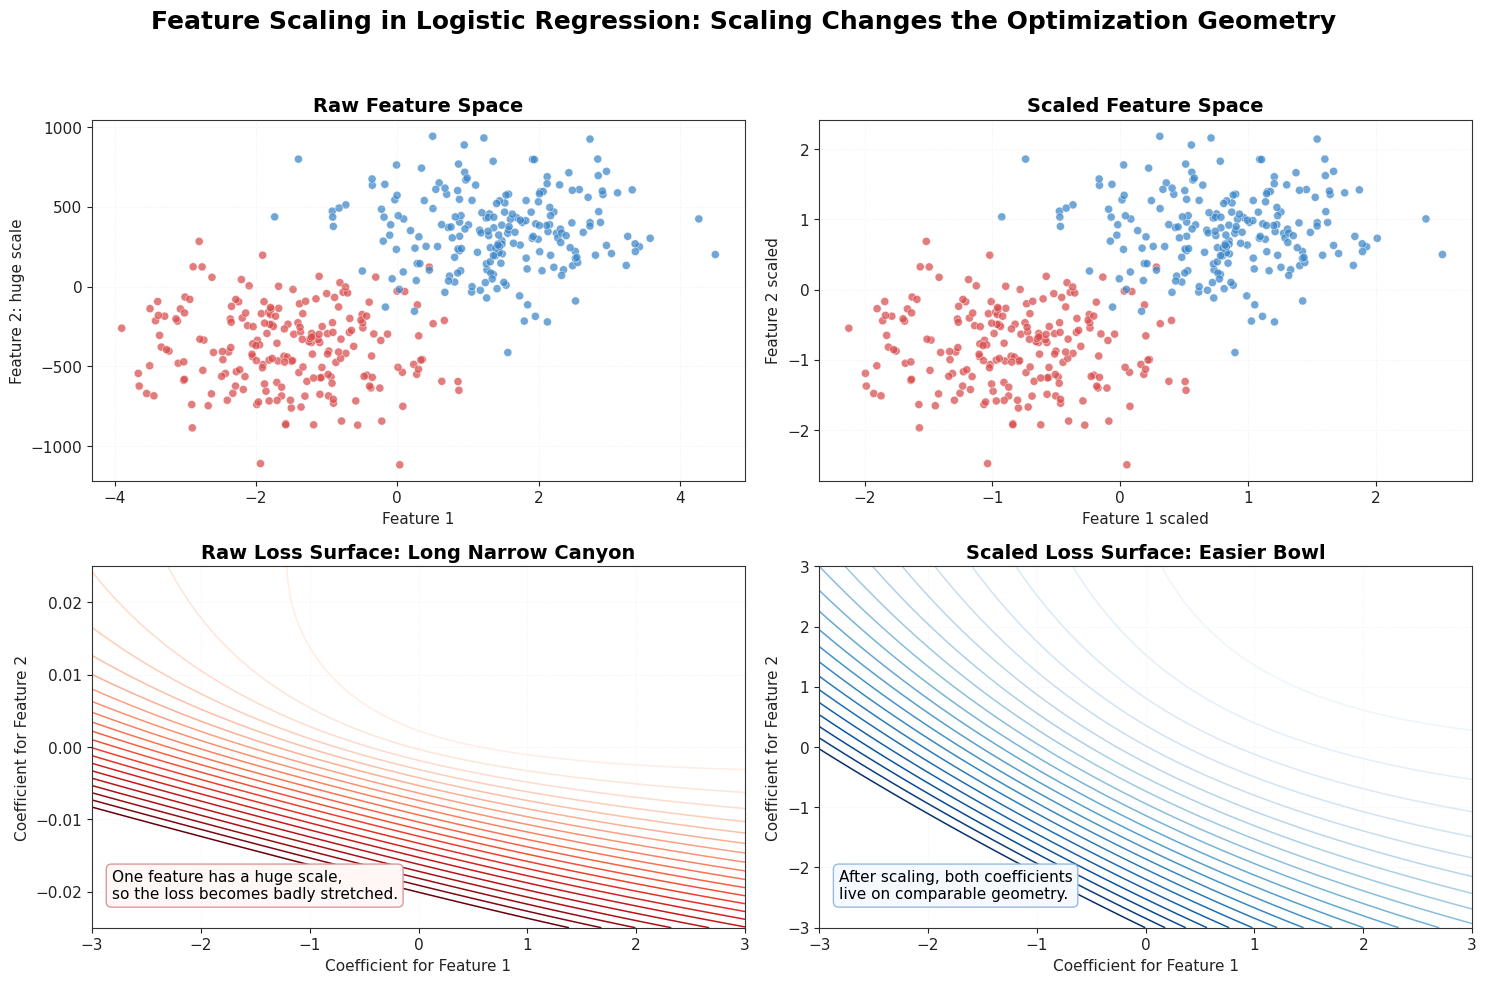

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from sklearn.preprocessing import StandardScaler

# ============================================================
# 1. Synthetic binary classification data
# ============================================================
np.random.seed(7)

n = 420
n0 = n // 2
n1 = n // 2

# Labels in {-1, +1}, convenient for logistic loss
y_signed = np.r_[np.full(n0, -1), np.full(n1, 1)]
y_color = (y_signed == 1).astype(int)

# Two useful features, but one is artificially made much larger
x1 = y_signed * 1.5 + np.random.normal(0, 1.05, n)
x2_small = y_signed * 1.5 + np.random.normal(0, 1.05, n)

X_raw = np.column_stack([
    x1,
    250 * x2_small          # same information, much larger scale
])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# ============================================================
# 2. Logistic regression trained manually with gradient descent
# ============================================================
def logistic_loss(X, y, w):
    margins = y * (X @ w)
    return np.mean(np.logaddexp(0, -margins))


def logistic_gradient(X, y, w):
    margins = y * (X @ w)
    # Stable enough for this visualization.
    weights = 1.0 / (1.0 + np.exp(np.clip(margins, -60, 60)))
    return np.mean((-y * weights)[:, None] * X, axis=0)


def accuracy(X, y, w):
    pred = np.where(X @ w >= 0, 1, -1)
    return np.mean(pred == y)


def gradient_descent_path(X, y, n_steps=180):
    # Smooth logistic loss has Lipschitz constant <= lambda_max(X^T X / n) / 4
    hessian_bound = np.linalg.eigvalsh((X.T @ X) / len(X)).max() / 4
    lr = 0.9 / hessian_bound

    w = np.array([0.0, 0.0])
    path = [w.copy()]
    losses = [logistic_loss(X, y, w)]
    accs = [accuracy(X, y, w)]

    for _ in range(n_steps):
        grad = logistic_gradient(X, y, w)
        w = w - lr * grad

        path.append(w.copy())
        losses.append(logistic_loss(X, y, w))
        accs.append(accuracy(X, y, w))

    return np.array(path), np.array(losses), np.array(accs), lr


raw_path, raw_losses, raw_accs, raw_lr = gradient_descent_path(X_raw, y_signed)
sc_path, sc_losses, sc_accs, sc_lr = gradient_descent_path(X_scaled, y_signed)

# ============================================================
# 3. Loss surfaces in coefficient space
# ============================================================
def make_loss_surface(X, y, w1_range, w2_range, grid_size=150):
    w1_vals = np.linspace(w1_range[0], w1_range[1], grid_size)
    w2_vals = np.linspace(w2_range[0], w2_range[1], grid_size)
    W1, W2 = np.meshgrid(w1_vals, w2_vals)

    W = np.column_stack([W1.ravel(), W2.ravel()])
    margins = y[:, None] * (X @ W.T)
    Z = np.mean(np.logaddexp(0, -margins), axis=0).reshape(W1.shape)

    return W1, W2, Z


# Raw coefficient for feature 2 is tiny because feature 2 has huge scale.
W1_raw, W2_raw, Z_raw = make_loss_surface(
    X_raw, y_signed,
    w1_range=(-3.0, 3.0),
    w2_range=(-0.025, 0.025)
)

W1_sc, W2_sc, Z_sc = make_loss_surface(
    X_scaled, y_signed,
    w1_range=(-3.0, 3.0),
    w2_range=(-3.0, 3.0)
)

def contour_levels(Z):
    low = Z.min()
    high = np.quantile(Z, 0.88)
    return np.linspace(low, high, 22)

levels_raw = contour_levels(Z_raw)
levels_sc = contour_levels(Z_sc)

# ============================================================
# 4. Plot setup
# ============================================================
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.labelcolor": "#222222",
    "xtick.color": "#222222",
    "ytick.color": "#222222",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold"
})

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

ax_data_raw = axes[0, 0]
ax_data_sc = axes[0, 1]
ax_loss_raw = axes[1, 0]
ax_loss_sc = axes[1, 1]

fig.suptitle(
    "Feature Scaling in Logistic Regression: Scaling Changes the Optimization Geometry",
    fontsize=18,
    fontweight="bold",
    y=0.98
)

colors = np.array(["#D94B4B", "#3A86C8"])

# ============================================================
# 5. Static top panels: data spaces
# ============================================================
ax_data_raw.scatter(
    X_raw[:, 0], X_raw[:, 1],
    c=colors[y_color],
    s=34,
    alpha=0.72,
    edgecolor="white",
    linewidth=0.4
)

ax_data_raw.set_title("Raw Feature Space")
ax_data_raw.set_xlabel("Feature 1")
ax_data_raw.set_ylabel("Feature 2: huge scale")
ax_data_raw.grid(True, alpha=0.2)

ax_data_sc.scatter(
    X_scaled[:, 0], X_scaled[:, 1],
    c=colors[y_color],
    s=34,
    alpha=0.72,
    edgecolor="white",
    linewidth=0.4
)

ax_data_sc.set_title("Scaled Feature Space")
ax_data_sc.set_xlabel("Feature 1 scaled")
ax_data_sc.set_ylabel("Feature 2 scaled")
ax_data_sc.grid(True, alpha=0.2)

# Decision boundary lines
raw_boundary, = ax_data_raw.plot([], [], color="black", linewidth=2.2)
sc_boundary, = ax_data_sc.plot([], [], color="black", linewidth=2.2)

raw_boundary_text = ax_data_raw.text(
    0.03, 0.96, "",
    transform=ax_data_raw.transAxes,
    va="top",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#CCCCCC")
)

sc_boundary_text = ax_data_sc.text(
    0.03, 0.96, "",
    transform=ax_data_sc.transAxes,
    va="top",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#CCCCCC")
)

# ============================================================
# 6. Static bottom panels: loss landscapes
# ============================================================
ax_loss_raw.contour(
    W1_raw, W2_raw, Z_raw,
    levels=levels_raw,
    cmap="Reds",
    linewidths=1.1
)

ax_loss_raw.set_title("Raw Loss Surface: Long Narrow Canyon")
ax_loss_raw.set_xlabel("Coefficient for Feature 1")
ax_loss_raw.set_ylabel("Coefficient for Feature 2")
ax_loss_raw.grid(True, alpha=0.18)

ax_loss_sc.contour(
    W1_sc, W2_sc, Z_sc,
    levels=levels_sc,
    cmap="Blues",
    linewidths=1.1
)

ax_loss_sc.set_title("Scaled Loss Surface: Easier Bowl")
ax_loss_sc.set_xlabel("Coefficient for Feature 1")
ax_loss_sc.set_ylabel("Coefficient for Feature 2")
ax_loss_sc.grid(True, alpha=0.18)

raw_path_line, = ax_loss_raw.plot([], [], color="black", linewidth=2.0)
raw_current_point, = ax_loss_raw.plot([], [], "o", color="gold", markeredgecolor="black", markersize=9)

sc_path_line, = ax_loss_sc.plot([], [], color="black", linewidth=2.0)
sc_current_point, = ax_loss_sc.plot([], [], "o", color="gold", markeredgecolor="black", markersize=9)

raw_loss_text = ax_loss_raw.text(
    0.03, 0.96, "",
    transform=ax_loss_raw.transAxes,
    va="top",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#CCCCCC")
)

sc_loss_text = ax_loss_sc.text(
    0.03, 0.96, "",
    transform=ax_loss_sc.transAxes,
    va="top",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#CCCCCC")
)

ax_loss_raw.text(
    0.03, 0.08,
    "One feature has a huge scale,\nso the loss becomes badly stretched.",
    transform=ax_loss_raw.transAxes,
    bbox=dict(boxstyle="round,pad=0.35", facecolor="#FFF6F6", edgecolor="#DD9999")
)

ax_loss_sc.text(
    0.03, 0.08,
    "After scaling, both coefficients\nlive on comparable geometry.",
    transform=ax_loss_sc.transAxes,
    bbox=dict(boxstyle="round,pad=0.35", facecolor="#F4F8FF", edgecolor="#99BBDD")
)

# ============================================================
# 7. Helpers for animated decision boundary
# ============================================================
def set_decision_boundary(line, ax, w):
    x_min, x_max = ax.get_xlim()
    xs = np.linspace(x_min, x_max, 200)

    if abs(w[1]) < 1e-10:
        line.set_data([], [])
        return

    ys = -(w[0] / w[1]) * xs
    line.set_data(xs, ys)


# ============================================================
# 8. Animation update
# ============================================================
n_frames = 120
frame_ids = np.linspace(0, len(raw_path) - 1, n_frames).astype(int)

def update(frame):
    i = frame_ids[frame]

    w_raw = raw_path[i]
    w_sc = sc_path[i]

    # Top: current classifier
    set_decision_boundary(raw_boundary, ax_data_raw, w_raw)
    set_decision_boundary(sc_boundary, ax_data_sc, w_sc)

    raw_boundary_text.set_text(
        f"Iteration {i}\n"
        f"Loss = {raw_losses[i]:.3f}\n"
        f"Accuracy = {raw_accs[i] * 100:.1f}%"
    )

    sc_boundary_text.set_text(
        f"Iteration {i}\n"
        f"Loss = {sc_losses[i]:.3f}\n"
        f"Accuracy = {sc_accs[i] * 100:.1f}%"
    )

    # Bottom: gradient descent paths
    raw_path_line.set_data(raw_path[:i + 1, 0], raw_path[:i + 1, 1])
    raw_current_point.set_data([w_raw[0]], [w_raw[1]])

    sc_path_line.set_data(sc_path[:i + 1, 0], sc_path[:i + 1, 1])
    sc_current_point.set_data([w_sc[0]], [w_sc[1]])

    raw_loss_text.set_text(
        f"Raw optimization\n"
        f"learning rate = {raw_lr:.2e}\n"
        f"loss = {raw_losses[i]:.3f}"
    )

    sc_loss_text.set_text(
        f"Scaled optimization\n"
        f"learning rate = {sc_lr:.2e}\n"
        f"loss = {sc_losses[i]:.3f}"
    )

    return [
        raw_boundary, sc_boundary,
        raw_path_line, raw_current_point,
        sc_path_line, sc_current_point,
        raw_boundary_text, sc_boundary_text,
        raw_loss_text, sc_loss_text
    ]


ani = animation.FuncAnimation(
    fig,
    update,
    frames=n_frames,
    interval=90,
    blit=False,
    repeat=True
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

# Optional save:
# ani.save("logistic_regression_scaling.gif", writer="pillow", fps=15)

plt.show()
# ============================================================
# IF USING JUPYTER/VS CODE: uncomment to show the animation 
#display(HTML(ani.to_jshtml()))

# 10. Cross-validation 🔀

A single train/test split can be unstable.

The result may depend on which subjects happen to be in the test set.

Cross-validation gives a more reliable estimate of performance.

---

## K-fold cross-validation

In K-fold cross-validation:

1. Split the data into $K$ parts.
2. Train the model on $K-1$ parts.
3. Test the model on the remaining part.
4. Repeat this process $K$ times.
5. Average the results.

---

## Formula

$$
\text{CV Score}
=
\frac{1}{K}
\sum_{k=1}^{K}
\text{Score}_k
$$

where:

- $K$ is the number of folds,
- $\text{Score}_k$ is the score from fold $k$.

---

## Example

If we use 5-fold cross-validation:

- the model trains and tests 5 times,
- each fold is used once for testing,
- the final score is the average of 5 scores.

---

## Why cross-validation is useful in neuroimaging

Neuroimaging datasets often have limited sample sizes.

Cross-validation uses data more efficiently than a single split.

Each subject is used for testing once and for training multiple times.

---

## Stratified cross-validation

For classification, we often use stratified cross-validation.

This keeps class proportions similar in each fold.

For example, if the full dataset has:
```text
40% control
35% MCI
25% AD

each fold should have approximately similar proportions.

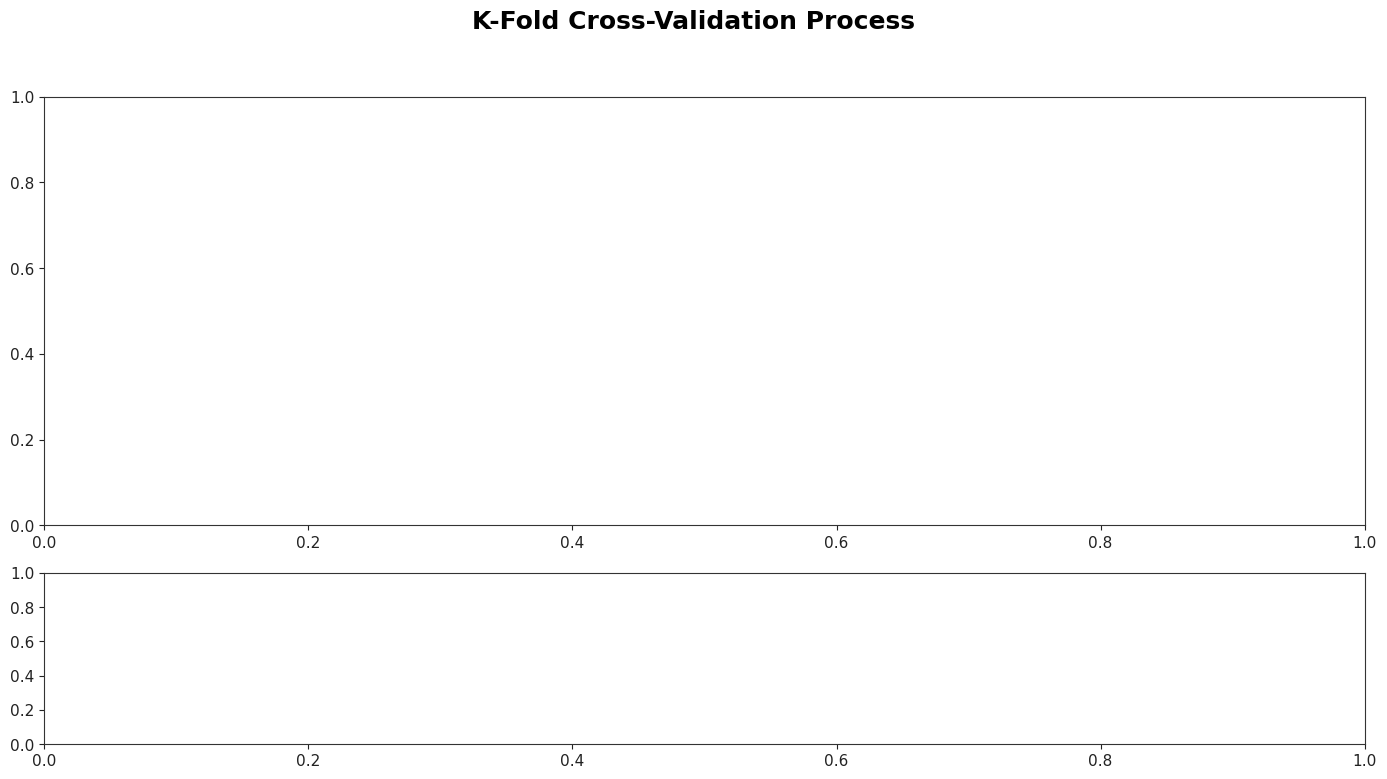

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from sklearn.model_selection import KFold

# ============================================================
# 1. Create simple indexed data
# ============================================================
np.random.seed(42)

n_samples = 60
X = np.arange(n_samples)

# Optional fake class labels just for color variety
y = np.array([0] * (n_samples // 2) + [1] * (n_samples - n_samples // 2))
perm = np.random.permutation(n_samples)
X = X[perm]
y = y[perm]

# ============================================================
# 2. K-Fold split
# ============================================================
k = 5
kf = KFold(n_splits=k, shuffle=False)

splits = list(kf.split(X))

# ============================================================
# 3. Layout helper
# ============================================================
n_cols = 10
n_rows = int(np.ceil(n_samples / n_cols))

grid_x = np.tile(np.arange(n_cols), n_rows)[:n_samples]
grid_y = np.repeat(np.arange(n_rows)[::-1], n_cols)[:n_samples]

# ============================================================
# 4. Styling
# ============================================================
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.labelcolor": "#222222",
    "xtick.color": "#222222",
    "ytick.color": "#222222",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold"
})

COLOR_UNUSED = "#D9D9D9"
COLOR_TRAIN = "#4C78A8"
COLOR_VALID = "#F58518"

# ============================================================
# 5. Figure
# ============================================================
fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 1, height_ratios=[3, 1.2])

ax_main = fig.add_subplot(gs[0, 0])
ax_bar = fig.add_subplot(gs[1, 0])

fig.suptitle(
    "K-Fold Cross-Validation Process",
    fontsize=18,
    fontweight="bold",
    y=0.97
)

# ============================================================
# 6. Main update
# ============================================================
def update(frame):
    fold_id = frame
    train_idx, valid_idx = splits[fold_id]

    colors = np.array([COLOR_UNUSED] * n_samples, dtype=object)
    colors[train_idx] = COLOR_TRAIN
    colors[valid_idx] = COLOR_VALID

    ax_main.clear()
    ax_bar.clear()

    # ---------------- Main panel ----------------
    ax_main.scatter(
        grid_x,
        grid_y,
        s=700,
        c=colors,
        edgecolor="black",
        linewidth=0.8
    )

    for i in range(n_samples):
        ax_main.text(
            grid_x[i],
            grid_y[i],
            str(i),
            ha="center",
            va="center",
            fontsize=9,
            color="white" if colors[i] in [COLOR_TRAIN, COLOR_VALID] else "black",
            fontweight="bold"
        )

    ax_main.set_title(f"Fold {fold_id + 1} of {k}")
    ax_main.set_xlim(-0.8, n_cols - 0.2)
    ax_main.set_ylim(-0.8, n_rows - 0.2)
    ax_main.set_xticks([])
    ax_main.set_yticks([])

    ax_main.text(
        0.02, 0.97,
        "Blue = Training samples\nOrange = Validation samples",
        transform=ax_main.transAxes,
        va="top",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="#CCCCCC")
    )

    # ---------------- Fold bar panel ----------------
    fold_sizes = [len(v) for _, v in splits]
    left = 0
    for i, size in enumerate(fold_sizes):
        color = COLOR_VALID if i == fold_id else "#D9D9D9"
        ax_bar.barh(
            [0],
            [size],
            left=left,
            color=color,
            edgecolor="white",
            height=0.45
        )
        ax_bar.text(
            left + size / 2,
            0,
            f"Fold {i + 1}",
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold"
        )
        left += size

    ax_bar.set_xlim(0, n_samples)
    ax_bar.set_ylim(-0.7, 0.7)
    ax_bar.set_yticks([])
    ax_bar.set_xlabel("Dataset samples")
    ax_bar.set_title("Current Validation Fold Moves Across the Dataset")
    ax_bar.grid(True, axis="x", alpha=0.2)

    ax_bar.text(
        0.02, 0.85,
        f"In this step:\nTrain on {len(train_idx)} samples\nValidate on {len(valid_idx)} samples",
        transform=ax_bar.transAxes,
        va="top",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="#CCCCCC")
    )

    return []

# ============================================================
# 7. Animate
# ============================================================
ani = animation.FuncAnimation(
    fig,
    update,
    frames=k,
    interval=1800,
    blit=False,
    repeat=True
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()
# ============================================================
# IF USING JUPYTER/VS CODE: uncomment to show the animation 
#display(HTML(ani.to_jshtml()))

# Optional save:
# ani.save("cross_validation_process.gif", writer="pillow", fps=1)


## 11. Classification metrics 📊

## Confusion matrix explained

A confusion matrix shows how classification predictions are distributed.

For binary classification, the confusion matrix contains four values:

| | Predicted Positive | Predicted Negative |
|---|---:|---:|
| Actual Positive | True Positive | False Negative |
| Actual Negative | False Positive | True Negative |

---

## True Positive

A true positive, or TP, means:

The true class is positive, and the model predicted positive.

Example:


A patient is correctly classified as patient.

---

## True Negative

A true negative, or TN, means:

The true class is negative, and the model predicted negative.

Example:


A control subject is correctly classified as control.

---

## False Positive

A false positive, or FP, means:


The true class is negative, but the model predicted positive.

Example:


A control subject is incorrectly classified as patient.

This is also called a false alarm.

---

## False Negative

A false negative, or FN, means:


The true class is positive, but the model predicted negative.

Example:


A patient is incorrectly classified as control.

This can be especially serious in clinical settings.


---

##  — Accuracy Explained


Accuracy measures the proportion of correct predictions.

It is defined as:

$$
\text{Accuracy}
=
\frac{TP + TN}{TP + TN + FP + FN}
$$

---

## In simple words

Accuracy answers:

Out of all predictions, how many were correct?

---

## Example

Suppose we classify 100 subjects.

The model gets 80 correct.

Then:

$$ \text{Accuracy} = \frac{80}{100} = 0.80 $$

So the accuracy is 80%.

---

## Limitation of accuracy

Accuracy can be misleading when classes are imbalanced.

Example:

Suppose 95% of subjects are controls and 5% are patients.

A model that always predicts "control" would have 95% accuracy.

But it would completely fail to identify patients.

So accuracy alone is not enough.


---

##  — Precision Explained

Precision measures how many predicted positives are actually positive.

It is defined as:

$$
\text{Precision}
=
\frac{TP}{TP + FP}
$$

---

## In simple words

Precision answers:

When the model predicts positive, how often is it correct?

---

## Example

Suppose the model predicts 20 subjects as patients.

Out of those 20, only 15 are truly patients.

Then:

$$ \text{Precision} = \frac{15}{20} = 0.75 $$

So precision is 75%.

---

## When precision matters

Precision matters when false positives are costly.

For example:

- incorrectly telling a healthy subject they may have disease,
- sending someone for unnecessary follow-up testing,
- enrolling the wrong participants in a clinical trial.

High precision means fewer false positives.


---

## — Recall Explained

Recall measures how many actual positives were correctly found.

It is defined as:

$$
\text{Recall}
=
\frac{TP}{TP + FN}
$$

---

## In simple words

Recall answers:

Out of all true positive cases, how many did the model detect?

---

## Example

Suppose there are 30 true patients.

The model correctly identifies 24 of them.

Then:

$$ \text{Recall} = \frac{24}{30} = 0.80 $$

So recall is 80%.

---

## When recall matters

Recall matters when false negatives are costly.

For example:

- missing a patient who actually has a disease,
- failing to detect high-risk individuals,
- incorrectly excluding someone from treatment.

High recall means fewer false negatives.


---

##  — F1-Score Explained

The F1-score combines precision and recall into one number.

It is defined as:

$$
F_1
=
2
\cdot
\frac{
\text{Precision}
\cdot
\text{Recall}
}{
\text{Precision}
+
\text{Recall}
}
$$

---

## Why not just average precision and recall?

The F1-score uses the harmonic mean.

The harmonic mean penalizes imbalance.

This means F1 is high only when both precision and recall are high.

---

## Example

Suppose:

$$
\text{Precision} = 0.90
$$

and:

$$
\text{Recall} = 0.30
$$

The model has high precision but low recall.

The F1-score will not be very high because recall is poor.

---

## When F1 is useful

F1-score is useful when:

- classes are imbalanced,
- both false positives and false negatives matter,
- we want one summary metric.

In medical and neuroimaging classification, F1-score is often more informative than accuracy alone.


## Macro, micro, and weighted averages

For multiclass classification, metrics such as precision, recall, and F1-score can be averaged in different ways.

Suppose we have three classes:

control, mci, ad

The metric can be computed separately for each class.

Then we need a way to summarize across classes.

---

## Macro average

Macro average computes the metric for each class and then takes the simple average.

Each class gets equal weight.

This is useful when we care equally about all classes.

For example:

$$ \text{Macro F1} = \frac{ F1_{\text{control}} + F1_{\text{mci}} + F1_{\text{ad}} }{3} $$

Macro average is sensitive to poor performance on minority classes.

---

## Weighted average

Weighted average computes the metric for each class and then averages them according to class size.

Larger classes get more weight.

This is useful when class imbalance exists and we want the metric to reflect the dataset distribution.

---

## Micro average

Micro average combines all true positives, false positives, and false negatives across classes first, then computes the metric.

This gives more weight to larger classes.

---

## Which one should we use?

In neuroimaging and clinical classification:

- report accuracy,
- report macro F1,
- inspect per-class precision and recall,
- show the confusion matrix.

Macro F1 is especially useful when minority classes are important.


---

## — ROC-AUC Explained

ROC-AUC is a classification metric based on predicted probabilities.

ROC stands for:

Receiver Operating Characteristic

AUC stands for:


Area Under the Curve

---

## Thresholds

Many classifiers output probabilities.

For example:

$$ \hat{p} = 0.70 $$

To turn this into a class label, we choose a threshold.

For binary classification, a common threshold is:

$$ 0.50 $$

If:

$$ \hat{p} \geq 0.50 $$

we predict class 1.

If:

$$ \hat{p} < 0.50 $$

we predict class 0.

---

## ROC curve

The ROC curve shows the tradeoff between:

- true positive rate,
- false positive rate,

across many possible thresholds.

The true positive rate is the same as recall:

$$ \text{TPR} = \frac{TP}{TP + FN} $$

The false positive rate is:

$$ \text{FPR} = \frac{FP}{FP + TN} $$

---

## AUC interpretation

AUC measures how well the model ranks positive cases above negative cases.

AUC values range from 0 to 1.

- 0.5 means random guessing.
- 1.0 means perfect ranking.
- below 0.5 means worse than random.

---

## Important note

ROC-AUC is most straightforward for binary classification.

For multiclass classification, special strategies such as one-vs-rest are used.

e:\anaconda\envs\basic\Lib\site-packages\matplotlib\animation.py:872: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


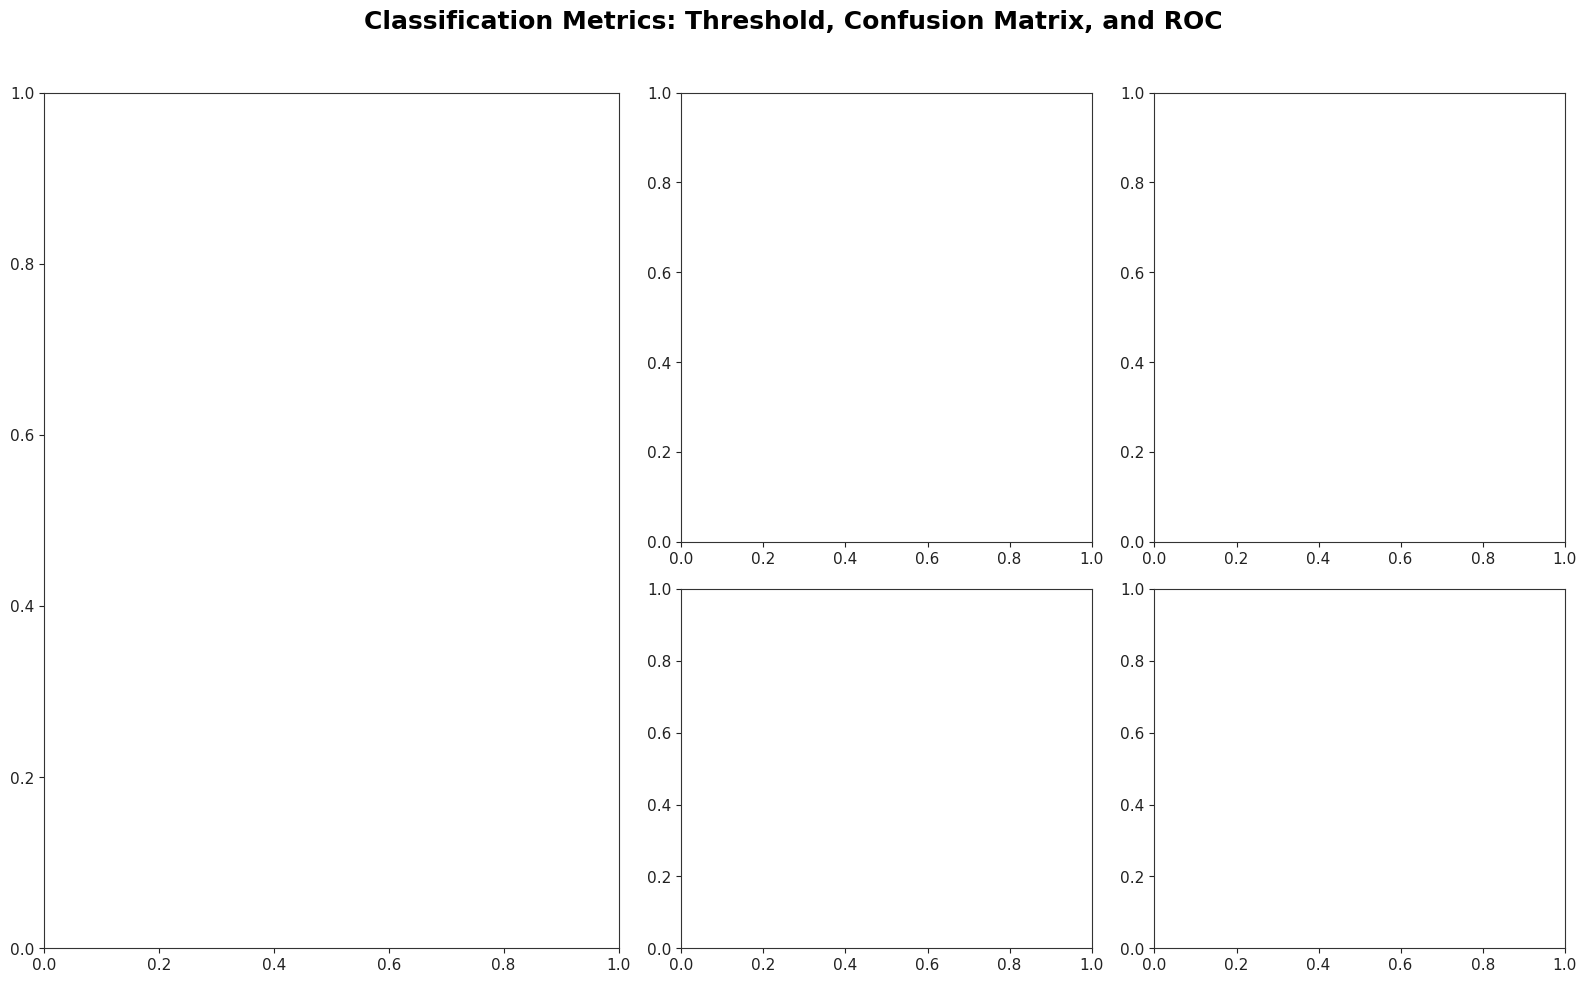

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Rectangle
from sklearn.metrics import roc_curve, auc, confusion_matrix

# ============================================================
# 1. Synthetic binary classification data
# ============================================================
np.random.seed(8)

n_neg = 70
n_pos = 30

# True labels: 0 = control, 1 = patient
y_true = np.r_[np.zeros(n_neg, dtype=int), np.ones(n_pos, dtype=int)]

# Simulated predicted probabilities
neg_scores = np.clip(np.random.normal(0.28, 0.16, n_neg), 0.01, 0.99)
pos_scores = np.clip(np.random.normal(0.72, 0.16, n_pos), 0.01, 0.99)
y_score = np.r_[neg_scores, pos_scores]

# Sort by score for a clean classroom display
order = np.argsort(y_score)
y_true = y_true[order]
y_score = y_score[order]

# Thresholds we animate through
thresholds = np.linspace(0.95, 0.05, 80)

# ROC curve from probabilities
fpr_curve, tpr_curve, roc_thresholds = roc_curve(y_true, y_score)
roc_auc = auc(fpr_curve, tpr_curve)

# ============================================================
# 2. Helpers
# ============================================================
def safe_div(a, b):
    return a / b if b != 0 else 0.0

def compute_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    accuracy = safe_div(tp + tn, tp + tn + fp + fn)
    precision = safe_div(tp, tp + fp)
    recall = safe_div(tp, tp + fn)
    f1 = safe_div(2 * precision * recall, precision + recall)

    tpr = recall
    fpr = safe_div(fp, fp + tn)

    return {
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "tpr": tpr,
        "fpr": fpr
    }

def current_predictions(scores, threshold):
    return (scores >= threshold).astype(int)

# Grid layout for subject icons
n_samples = len(y_true)
n_cols = 10
n_rows = int(np.ceil(n_samples / n_cols))
grid_x = np.tile(np.arange(n_cols), n_rows)[:n_samples]
grid_y = np.repeat(np.arange(n_rows)[::-1], n_cols)[:n_samples]

# ============================================================
# 3. Styling
# ============================================================
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.labelcolor": "#222222",
    "xtick.color": "#222222",
    "ytick.color": "#222222",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold"
})

C_TP = "#2A9D8F"
C_TN = "#4C78A8"
C_FP = "#F4A261"
C_FN = "#E76F51"

# ============================================================
# 4. Figure
# ============================================================
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3, height_ratios=[1.25, 1], width_ratios=[1.4, 1, 1])

ax_subjects = fig.add_subplot(gs[:, 0])
ax_cm = fig.add_subplot(gs[0, 1])
ax_metrics = fig.add_subplot(gs[0, 2])
ax_roc = fig.add_subplot(gs[1, 1])
ax_formulas = fig.add_subplot(gs[1, 2])

fig.suptitle(
    "Classification Metrics: Threshold, Confusion Matrix, and ROC",
    fontsize=18,
    fontweight="bold",
    y=0.98
)

# ============================================================
# 5. Animation update
# ============================================================
def update(frame):
    threshold = thresholds[frame]
    y_pred = current_predictions(y_score, threshold)
    m = compute_metrics(y_true, y_pred)

    ax_subjects.clear()
    ax_cm.clear()
    ax_metrics.clear()
    ax_roc.clear()
    ax_formulas.clear()

    # --------------------------------------------------------
    # Panel A: subjects laid out as icons
    # --------------------------------------------------------
    colors = []
    labels = []
    for yt, yp in zip(y_true, y_pred):
        if yt == 1 and yp == 1:
            colors.append(C_TP)
            labels.append("TP")
        elif yt == 0 and yp == 0:
            colors.append(C_TN)
            labels.append("TN")
        elif yt == 0 and yp == 1:
            colors.append(C_FP)
            labels.append("FP")
        else:
            colors.append(C_FN)
            labels.append("FN")

    ax_subjects.scatter(
        grid_x, grid_y,
        s=760, c=colors,
        edgecolor="black", linewidth=0.8
    )

    for i in range(n_samples):
        ax_subjects.text(
            grid_x[i], grid_y[i],
            f"{y_score[i]:.2f}",
            ha="center", va="center",
            fontsize=8, fontweight="bold",
            color="white"
        )

    ax_subjects.set_title("Subjects: predicted probability and outcome type")
    ax_subjects.set_xlim(-0.8, n_cols - 0.2)
    ax_subjects.set_ylim(-0.8, n_rows - 0.2)
    ax_subjects.set_xticks([])
    ax_subjects.set_yticks([])

    ax_subjects.text(
        0.02, 0.98,
        f"Threshold = {threshold:.2f}\n"
        f"Green = TP   Blue = TN\n"
        f"Orange = FP  Red = FN",
        transform=ax_subjects.transAxes,
        va="top",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="#CCCCCC")
    )

    ax_subjects.text(
        0.02, 0.03,
        "Each circle = one subject\nNumber inside = predicted probability of 'patient'",
        transform=ax_subjects.transAxes,
        va="bottom",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="#CCCCCC")
    )

    # --------------------------------------------------------
    # Panel B: confusion matrix
    # --------------------------------------------------------
    ax_cm.set_title("Confusion Matrix")
    ax_cm.set_xlim(0, 2)
    ax_cm.set_ylim(0, 2)
    ax_cm.set_xticks([0.5, 1.5])
    ax_cm.set_yticks([0.5, 1.5])
    ax_cm.set_xticklabels(["Predicted Positive", "Predicted Negative"])
    ax_cm.set_yticklabels(["Actual Positive", "Actual Negative"])
    ax_cm.invert_yaxis()

    cells = [
        (0, 0, C_TP, f"TP\n{m['TP']}"),
        (1, 0, C_FN, f"FN\n{m['FN']}"),
        (0, 1, C_FP, f"FP\n{m['FP']}"),
        (1, 1, C_TN, f"TN\n{m['TN']}")
    ]

    for x, y, color, txt in cells:
        ax_cm.add_patch(Rectangle((x, y), 1, 1, facecolor=color, edgecolor="white", linewidth=3))
        ax_cm.text(x + 0.5, y + 0.5, txt, ha="center", va="center",
                   fontsize=14, fontweight="bold", color="white")

    for spine in ax_cm.spines.values():
        spine.set_visible(False)

    # --------------------------------------------------------
    # Panel C: metric bars
    # --------------------------------------------------------
    metric_names = ["Accuracy", "Precision", "Recall", "F1-score"]
    metric_values = [m["accuracy"], m["precision"], m["recall"], m["f1"]]
    metric_colors = ["#577590", "#F8961E", "#43AA8B", "#7B2CBF"]

    ax_metrics.bar(metric_names, metric_values, color=metric_colors, edgecolor="black")
    ax_metrics.set_ylim(0, 1.05)
    ax_metrics.set_title("Derived Classification Metrics")
    ax_metrics.set_ylabel("Score")
    ax_metrics.grid(True, axis="y", alpha=0.25)

    for i, v in enumerate(metric_values):
        ax_metrics.text(i, v + 0.03, f"{v:.2f}", ha="center", fontweight="bold")

    # --------------------------------------------------------
    # Panel D: ROC curve with current threshold point
    # --------------------------------------------------------
    ax_roc.plot(fpr_curve, tpr_curve, color="#1D3557", linewidth=2.5, label=f"ROC curve (AUC = {roc_auc:.3f})")
    ax_roc.plot([0, 1], [0, 1], "--", color="gray", alpha=0.7, label="Random guessing")

    ax_roc.scatter(m["fpr"], m["tpr"], s=120, color="crimson", edgecolor="black", zorder=5)
    ax_roc.text(
        m["fpr"] + 0.02, m["tpr"] - 0.05,
        f"threshold={threshold:.2f}",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="#CCCCCC")
    )

    ax_roc.set_xlim(-0.02, 1.02)
    ax_roc.set_ylim(-0.02, 1.02)
    ax_roc.set_xlabel("False Positive Rate = FP / (FP + TN)")
    ax_roc.set_ylabel("True Positive Rate = TP / (TP + FN)")
    ax_roc.set_title("ROC Curve")
    ax_roc.grid(True, alpha=0.25)
    ax_roc.legend(loc="lower right")

    # --------------------------------------------------------
    # Panel E: formulas and interpretation
    # --------------------------------------------------------
    ax_formulas.axis("off")
    ax_formulas.set_title("Metric Definitions")

    text = (
        f"Accuracy = (TP + TN) / All = {m['accuracy']:.2f}\n\n"
        f"Precision = TP / (TP + FP) = {m['precision']:.2f}\n"
        f"When we predict positive,\n"
        f"how often are we correct?\n\n"
        f"Recall = TP / (TP + FN) = {m['recall']:.2f}\n"
        f"Out of all true positives,\n"
        f"how many did we find?\n\n"
        f"F1 = harmonic mean of precision and recall = {m['f1']:.2f}\n\n"
        f"ROC point:\n"
        f"TPR = {m['tpr']:.2f}, FPR = {m['fpr']:.2f}"
    )

    ax_formulas.text(
        0.03, 0.95, text,
        va="top",
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.45", facecolor="white", edgecolor="#CCCCCC")
    )

    return []

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(thresholds),
    interval=180,
    blit=False,
    repeat=True
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
# ============================================================
# IF USING JUPYTER/VS CODE: uncomment to show the animation 
#display(HTML(ani.to_jshtml()))


# Optional save:
# ani.save("classification_metrics_binary.gif", writer="pillow", fps=8)


# 12. Regression metrics 📈

For regression tasks, common evaluation metrics include MAE, MSE, RMSE, and $R^2$.

---

## Mean Absolute Error

$$
\text{MAE}
=
\frac{1}{n}
\sum_{i=1}^{n}
|y_i - \hat{y}_i|
$$

MAE is easy to interpret because it is in the same unit as the target.

---

## Mean Squared Error

$$
\text{MSE}
=
\frac{1}{n}
\sum_{i=1}^{n}
(y_i - \hat{y}_i)^2
$$

MSE penalizes large errors more strongly.

---

## Root Mean Squared Error

$$
\text{RMSE}
=
\sqrt{
\frac{1}{n}
\sum_{i=1}^{n}
(y_i - \hat{y}_i)^2
}
$$

RMSE is also in the same unit as the target.

---

## Coefficient of determination

The coefficient of determination is:

$$
R^2
=
1
-
\frac{
\sum_{i=1}^{n}
(y_i - \hat{y}_i)^2
}{
\sum_{i=1}^{n}
(y_i - \bar{y})^2
}
$$

where:

- $\bar{y}$ is the mean of the true target values.

An $R^2$ value close to 1 means better prediction.

## — R-Squared Explained

$R^2$ is a common regression metric.

It measures how much variance in the target is explained by the model.

The formula is:

$$
R^2
=
1
-
\frac{
\sum_{i=1}^{n}
(y_i - \hat{y}_i)^2
}{
\sum_{i=1}^{n}
(y_i - \bar{y})^2
}
$$

where:

- $y_i$ is the true value,
- $\hat{y}_i$ is the predicted value,
- $\bar{y}$ is the mean of the true values.

---

## What does this mean?

The numerator is the model's squared error:

$$
\sum_{i=1}^{n}
(y_i - \hat{y}_i)^2
$$

The denominator is the error from a simple baseline model that always predicts the mean:

$$
\sum_{i=1}^{n}
(y_i - \bar{y})^2
$$

So $R^2$ compares the model to a simple mean-prediction baseline.

---

## Interpretation

If:

$$
R^2 = 1
$$

the model predicts perfectly.

If:

$$
R^2 = 0
$$

the model is no better than always predicting the mean.

If:

$$
R^2 < 0
$$

the model is worse than predicting the mean.

---

## Important warning

A high training $R^2$ does not always mean a good model.

If test $R^2$ is much lower than training $R^2$, the model may be overfitting.

## Choosing regression metrics

Different regression metrics answer different questions.

---

## MAE

MAE answers:

On average, how far are predictions from the true values?

It is easy to understand.

If predicting age:


MAE = 5

means the average absolute error is about 5 years.

---

## RMSE

RMSE answers:


What is the typical error, with large mistakes penalized more strongly?

RMSE is useful when large errors are especially undesirable.

---

## MSE

MSE is useful mathematically and for optimization.

However, because it is in squared units, it is harder to interpret directly.

---

## R-squared

$R^2$ answers:


How much better is the model than simply predicting the mean?

It is useful for understanding relative explanatory power.

---

## Recommended reporting

For regression, it is often good to report:

- MAE,
- RMSE,
- $R^2$.

Together, these give a more complete view of performance.


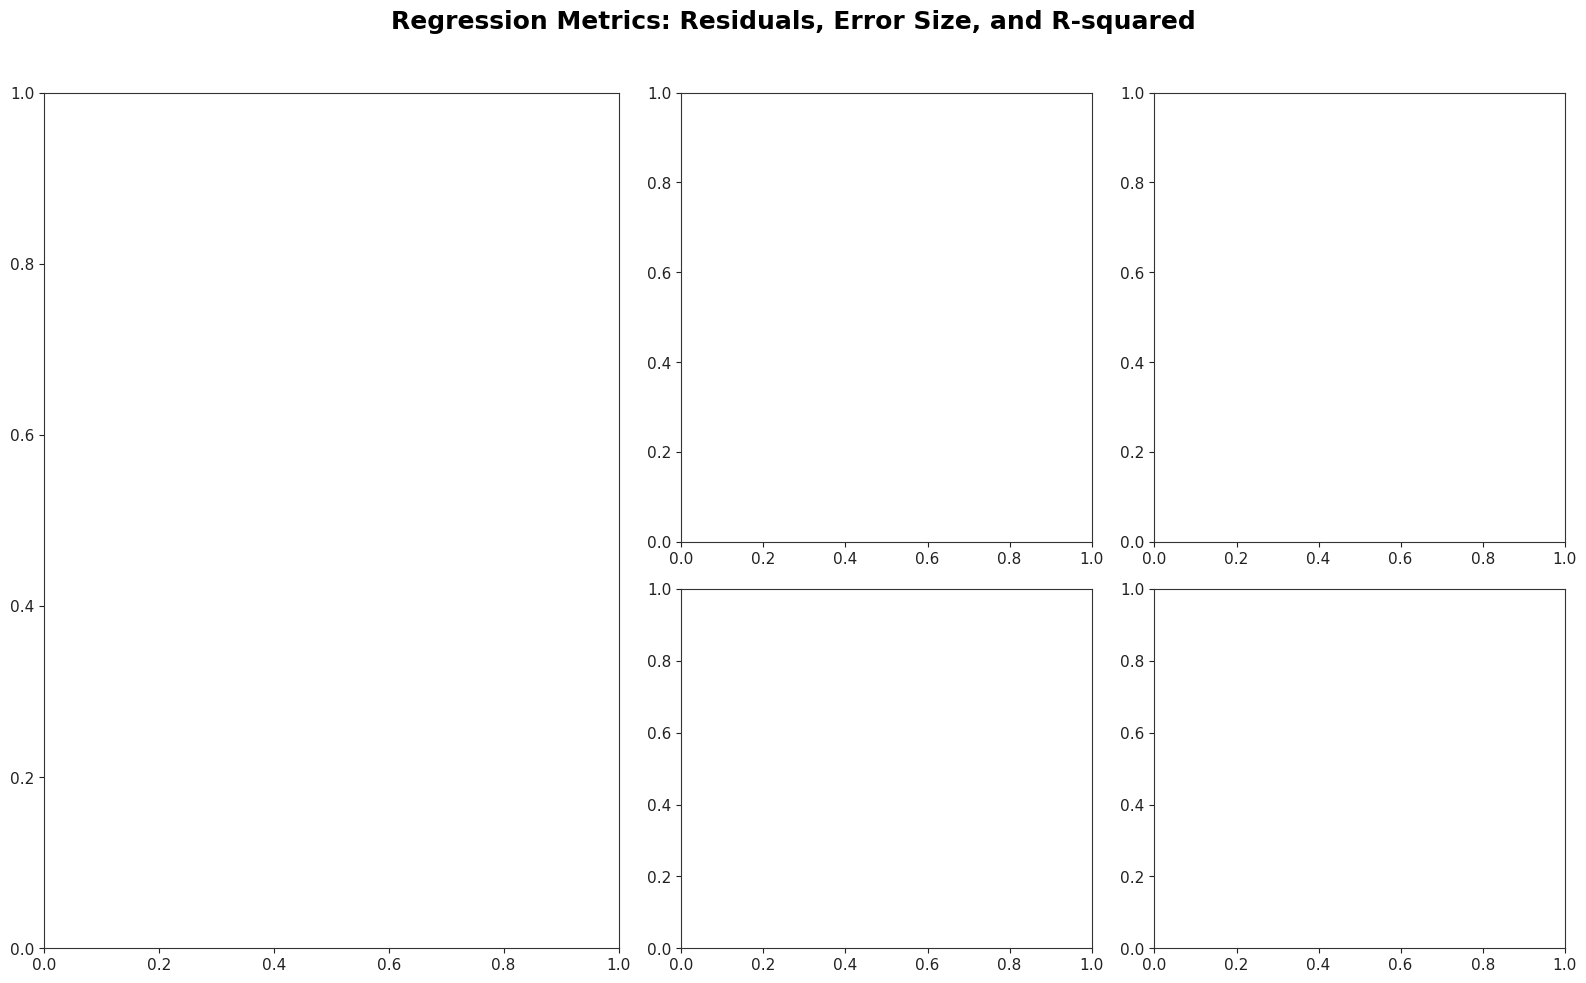

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# ============================================================
# 1. Synthetic regression data
# ============================================================
np.random.seed(10)

n = 45
x = np.linspace(0, 10, n)
y_true = 3.0 + 2.4 * x + np.random.normal(0, 2.2, n)

y_mean = np.mean(y_true)
ss_tot = np.sum((y_true - y_mean) ** 2)

# We animate a model gradually improving from bad to good
w0_start, w1_start = 16.0, -0.9
w0_end, w1_end = 3.2, 2.35

n_frames = 100
t_vals = np.linspace(0, 1, n_frames)

# Smooth progress so early improvement is visible
progress = 1 - (1 - t_vals) ** 2

# ============================================================
# 2. Metric helpers
# ============================================================
def regression_metrics(y, yhat):
    residuals = y - yhat
    mae = np.mean(np.abs(residuals))
    mse = np.mean(residuals ** 2)
    rmse = np.sqrt(mse)
    ss_res = np.sum(residuals ** 2)
    r2 = 1 - ss_res / ss_tot
    return residuals, mae, mse, rmse, r2, ss_res

# ============================================================
# 3. Styling
# ============================================================
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.labelcolor": "#222222",
    "xtick.color": "#222222",
    "ytick.color": "#222222",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold"
})

C_TRUE = "#1D3557"
C_PRED = "#D62828"
C_RES = "#2A9D8F"
C_BASE = "#888888"

# ============================================================
# 4. Figure
# ============================================================
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3, height_ratios=[1.25, 1], width_ratios=[1.4, 1, 1])

ax_fit = fig.add_subplot(gs[:, 0])
ax_resid = fig.add_subplot(gs[0, 1])
ax_metrics = fig.add_subplot(gs[0, 2])
ax_r2 = fig.add_subplot(gs[1, 1])
ax_text = fig.add_subplot(gs[1, 2])

fig.suptitle(
    "Regression Metrics: Residuals, Error Size, and R-squared",
    fontsize=18,
    fontweight="bold",
    y=0.98
)

# ============================================================
# 5. Animation update
# ============================================================
def update(frame):
    p = progress[frame]

    w0 = (1 - p) * w0_start + p * w0_end
    w1 = (1 - p) * w1_start + p * w1_end
    y_pred = w0 + w1 * x

    residuals, mae, mse, rmse, r2, ss_res = regression_metrics(y_true, y_pred)

    ax_fit.clear()
    ax_resid.clear()
    ax_metrics.clear()
    ax_r2.clear()
    ax_text.clear()

    # --------------------------------------------------------
    # Panel A: data, prediction line, and residuals
    # --------------------------------------------------------
    ax_fit.scatter(x, y_true, s=60, color=C_TRUE, edgecolor="white", linewidth=0.6, label="True values")
    ax_fit.plot(x, y_pred, color=C_PRED, linewidth=2.8, label="Model prediction")
    ax_fit.axhline(y_mean, color=C_BASE, linestyle="--", linewidth=2, label="Mean baseline")

    for xi, yi, yhi in zip(x, y_true, y_pred):
        ax_fit.plot([xi, xi], [yi, yhi], color=C_RES, alpha=0.6, linewidth=1.5)

    ax_fit.set_title("Regression Fit and Residuals")
    ax_fit.set_xlabel("Feature")
    ax_fit.set_ylabel("Target")
    ax_fit.grid(True, alpha=0.25)
    ax_fit.legend(loc="upper left")

    ax_fit.text(
        0.02, 0.98,
        f"Model: y_hat = {w0:.2f} + {w1:.2f} x\n"
        f"Residual = y - y_hat",
        transform=ax_fit.transAxes,
        va="top",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="#CCCCCC")
    )

    # --------------------------------------------------------
    # Panel B: residual magnitudes
    # --------------------------------------------------------
    idx = np.arange(len(residuals))
    abs_res = np.abs(residuals)
    sq_res = residuals ** 2

    width = 0.4
    ax_resid.bar(idx - width / 2, abs_res, width=width, color="#F4A261", edgecolor="black", label="|error|")
    ax_resid.bar(idx + width / 2, sq_res, width=width, color="#E76F51", edgecolor="black", label="error^2")

    ax_resid.set_title("Absolute vs Squared Errors")
    ax_resid.set_xlabel("Sample index")
    ax_resid.set_ylabel("Error contribution")
    ax_resid.grid(True, axis="y", alpha=0.25)
    ax_resid.legend(loc="upper right")

    ax_resid.text(
        0.02, 0.97,
        "MAE averages |errors|\nMSE averages squared errors\nLarge mistakes grow much more in MSE",
        transform=ax_resid.transAxes,
        va="top",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="#CCCCCC")
    )

    # --------------------------------------------------------
    # Panel C: metric bars
    # --------------------------------------------------------
    metric_names = ["MAE", "MSE", "RMSE", "R^2"]
    metric_values = [mae, mse, rmse, r2]
    metric_colors = ["#F4A261", "#E76F51", "#43AA8B", "#577590"]

    bars = ax_metrics.bar(metric_names, metric_values, color=metric_colors, edgecolor="black")
    ax_metrics.set_title("Regression Metrics")
    ax_metrics.grid(True, axis="y", alpha=0.25)

    upper = max(max(mse, rmse, mae) * 1.15, 1.0)
    ax_metrics.set_ylim(min(-0.4, r2 - 0.1), upper)

    for b, v in zip(bars, metric_values):
        ax_metrics.text(
            b.get_x() + b.get_width() / 2,
            v + (0.03 * upper if v >= 0 else -0.08),
            f"{v:.2f}",
            ha="center",
            fontweight="bold"
        )

    # --------------------------------------------------------
    # Panel D: R^2 as model error vs baseline error
    # --------------------------------------------------------
    ax_r2.bar(
        ["Model SSE", "Mean Baseline SSE"],
        [ss_res, ss_tot],
        color=[C_PRED, C_BASE],
        edgecolor="black"
    )
    ax_r2.set_title("R^2 Compares Model to Mean Baseline")
    ax_r2.set_ylabel("Sum of Squared Errors")
    ax_r2.grid(True, axis="y", alpha=0.25)

    ax_r2.text(
        0.02, 0.97,
        f"R^2 = 1 - SSE_model / SSE_mean = {r2:.3f}\n\n"
        f"R^2 = 1   : perfect fit\n"
        f"R^2 = 0   : same as predicting the mean\n"
        f"R^2 < 0   : worse than mean baseline",
        transform=ax_r2.transAxes,
        va="top",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="#CCCCCC")
    )

    # --------------------------------------------------------
    # Panel E: interpretation
    # --------------------------------------------------------
    ax_text.axis("off")
    ax_text.set_title("How to Read These Metrics")

    text = (
        f"MAE = {mae:.2f}\n"
        f"Average absolute error.\n"
        f"Easy to interpret in target units.\n\n"
        f"MSE = {mse:.2f}\n"
        f"Average squared error.\n"
        f"Punishes large errors more strongly.\n\n"
        f"RMSE = {rmse:.2f}\n"
        f"Square root of MSE.\n"
        f"Back in target units.\n\n"
        f"R^2 = {r2:.2f}\n"
        f"How much better the model is\n"
        f"than predicting the mean."
    )

    ax_text.text(
        0.03, 0.95, text,
        va="top",
        bbox=dict(boxstyle="round,pad=0.45", facecolor="white", edgecolor="#CCCCCC")
    )

    return []

ani = animation.FuncAnimation(
    fig,
    update,
    frames=n_frames,
    interval=120,
    blit=False,
    repeat=True
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
# ============================================================
# IF USING JUPYTER/VS CODE: uncomment to show the animation 
#display(HTML(ani.to_jshtml()))

# Optional save:
# ani.save("regression_metrics_animation.gif", writer="pillow", fps=10)


## 13. Data leakage 💧

Data leakage occurs when information from the test set accidentally influences the training process.

This can produce overly optimistic performance estimates.

---

## Why leakage is dangerous

The test set is supposed to represent unseen future data.

If the model gets information from the test set during training, then the test set is no longer truly unseen.

This gives an overly optimistic estimate of performance.

---

## Common sources of leakage

Examples include:

- scaling the full dataset before splitting,
- imputing missing values before splitting,
- selecting features using the full dataset,
- tuning hyperparameters on the test set,
- using subject information that would not be available in real prediction settings.

---

## Incorrect workflow

A risky workflow is:

Scale full dataset → Split into train/test → Train model → Evaluate

This leaks information from the test set into preprocessing.

---

## Correct workflow

A safer workflow is:


Split into train/test → Fit preprocessing on train only → Apply to test → Evaluate

In scikit-learn, `Pipeline` helps enforce this correct workflow.



## 14. Hyperparameters and model selection

Model parameters are learned from the data.

Hyperparameters are settings chosen before or during model selection.
## — Parameters vs Hyperparameters

It is important to distinguish between parameters and hyperparameters.

---

## Parameters

Parameters are learned from the data.

Examples:

- regression coefficients,
- logistic regression coefficients,
- neural network weights.

For linear regression:

$$
\hat{y}
=
\beta_0
+
\beta_1x_1
+
\beta_2x_2
+
\cdots
+
\beta_px_p
$$

The coefficients:

$$
\beta_0, \beta_1, \dots, \beta_p
$$

are parameters.

The model learns them during training.

---

## Hyperparameters

Hyperparameters are settings chosen before or during model selection.

Examples:

- regularization strength,
- number of trees in a random forest,
- polynomial degree,
- learning rate,
- number of folds in cross-validation.

The model does not directly learn these in the same way.

We usually select them using validation data or cross-validation.

---

## Important point

The test set should not be used to choose hyperparameters.

If we use the test set for model selection, it is no longer an unbiased test set.

Examples:

- Ridge regression: $\alpha$
- Lasso regression: $\alpha$
- Logistic regression: regularization strength $C$
- Polynomial regression: polynomial degree
- Random forest: number of trees and tree depth

---

## Regularization strength

In Ridge and Lasso, larger $\alpha$ means stronger regularization.

In logistic regression, the parameter $C$ is the inverse of regularization strength:

$$
C
=
\frac{1}{\lambda}
$$

Therefore:

- smaller $C$ means stronger regularization,
- larger $C$ means weaker regularization.


## 15. Safer end-to-end workflow 🏗️

A safer machine learning workflow usually follows these steps:

1. Define the prediction task.
2. Separate features and target.
3. Split the data into training and test sets.
4. Build a pipeline containing preprocessing and modeling.
5. Fit the pipeline only on the training data.
6. Evaluate once on the test data.
7. Use cross-validation for model comparison.
8. Report multiple metrics, not just one.
9. Interpret results carefully.

---

## Neuroimaging-specific reminders

When working with neuroimaging data:

- keep preprocessing inside cross-validation when possible,
- avoid using test data for feature selection,
- control for confounds carefully,
- check class imbalance,
- report uncertainty,
- validate on independent data when available.


## Conceptual summary

This notebook introduced the foundations of machine learning for neuroimaging.

---

## 1. Supervised learning

Supervised learning uses labeled examples.

The model learns a function:

$$
\hat{y} = f(X)
$$

The goal is to make predictions that are close to the true target values.

---

## 2. Loss functions

A loss function measures prediction error.

For regression, common losses include:

$$
\text{MSE}
=
\frac{1}{n}
\sum_{i=1}^{n}
(y_i - \hat{y}_i)^2
$$

For classification, cross-entropy is commonly used.

The model tries to minimize the loss.

---

## 3. Optimization

Optimization is the process of finding model parameters that minimize the loss:

$$
\theta^*
=
\arg\min_{\theta}
\mathcal{L}(\theta)
$$

Gradient descent is one common optimization algorithm.

It updates parameters using:

$$
\theta_{t+1}
=
\theta_t
-
\eta
\nabla_{\theta}
\mathcal{L}(\theta_t)
$$

---

## 4. Generalization

The goal is not just good training performance.

The goal is good test performance.

Good generalization means the model works well on unseen data.

---

## 5. Underfitting and overfitting

Underfitting means the model is too simple.

Overfitting means the model is too complex.

A good model balances simplicity and flexibility.

---

## 6. Bias-variance tradeoff

Prediction error can be understood as:

$$
\text{Error}
=
\text{Bias}^2
+
\text{Variance}
+
\text{Irreducible Error}
$$

High bias causes underfitting.

High variance causes overfitting.

---

## 7. Regularization

Regularization reduces overfitting by penalizing model complexity.

Ridge uses an L2 penalty.

Lasso uses an L1 penalty.

Elastic Net combines both.

---

## 8. Scaling

Scaling puts features on comparable numeric ranges.

This is important for many models, including logistic regression, ridge, lasso, SVMs, and neural networks.

---

## 9. Cross-validation

Cross-validation gives a more reliable estimate of model performance than a single split.

It is especially useful in neuroimaging because datasets are often small.

---

## 10. Metrics

Classification metrics include:

- accuracy,
- precision,
- recall,
- F1-score,
- ROC-AUC,
- confusion matrix.

Regression metrics include:

- MAE,
- MSE,
- RMSE,
- $R^2$.

No single metric tells the whole story.

Good evaluation usually requires multiple metrics.

---

## Final message

Reliable machine learning is not only about building a model with high accuracy.

It is about building a full workflow that is:

- statistically valid,
- resistant to leakage,
- interpretable,
- reproducible,
- and trustworthy on new data.


# End of Session 2 ✅

You have now built a foundation for understanding:

- supervised learning,
- optimization,
- loss functions,
- generalization,
- overfitting,
- regularization,
- scaling,
- cross-validation,
- classification metrics,
- regression metrics,
- and safe machine learning workflows.

These concepts will support more advanced models in later sessions.
